<a href="https://colab.research.google.com/github/vikashkumar-raj/AI-Candlestick-Prediction/blob/main1/Gold_AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# AI-Powered Gold Trading Decision Support System
# Phase 1 : Dataset Loading & Validation
# Author : Team
# ==========================================================
# !nvidia-smi

In [2]:
import tensorflow as tf
import os

print("==========================================================")
print("⚙️ ENHANCED GPU & MIXED PRECISION INITIALIZATION")
print("==========================================================")

# 1. Force TensorFlow to only log critical operations (Clean environment)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 2. Configure Memory Growth and Device Placement Logging
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        # GPU mapping details print karega debug karne ke liye
        tf.config.set_soft_device_placement(True)
        print(f"✓ Institutional GPU Stack Active. Total Available GPUs: {len(gpus)}")
        print(f"✓ Active Device Name: {tf.test.gpu_device_name()}")
    except RuntimeError as e:
        print(f"⚠️ GPU Configuration Exception: {e}")
else:
    print("❌ CRITICAL WARNING: No GPU detected by TensorFlow! Go to Runtime -> Change runtime type -> Select T4 GPU.")

# 3. Modern Keras 3 Way for Mixed Precision Setup (Compatible with TF 2.20+)
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print(f"✓ Global Mixed Precision Engaged: {tf.keras.mixed_precision.global_policy().name}")
    print("  [INFO] Tensor Cores will now process matrix multiplications in Float16.")
except Exception as e:
    print(f"⚠️ Mixed Precision Configuration Failed: {e}")

print(f"✓ TensorFlow Engine Version: {tf.__version__}")
print("==========================================================")

⚙️ ENHANCED GPU & MIXED PRECISION INITIALIZATION
❌ CRITICAL WARNING: No GPU detected by TensorFlow! Go to Runtime -> Change runtime type -> Select T4 GPU.
✓ Global Mixed Precision Engaged: mixed_float16
  [INFO] Tensor Cores will now process matrix multiplications in Float16.
✓ TensorFlow Engine Version: 2.20.0


In [3]:
# ==============================
# Import Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [4]:
# ==============================
# Load Dataset
# ==============================

from google.colab import drive
drive.mount('/content/drive')

# 2. Exact file path define karein
file_path = '/content/drive/MyDrive/Gold-AI-Trading-System/datasets/XAU_15m_data.csv'

# 3. Data load karein
try:
    df = pd.read_csv(file_path)
    print("✓ Data successfully load ho gaya hai!\n")
except FileNotFoundError:
    print("❌ Error: File path check karein. Folder ka naam exact match hona chahiye.")

Mounted at /content/drive
✓ Data successfully load ho gaya hai!



In [5]:
print("="*60)

print("Shape")
print(df.shape)

print("="*60)

print("Columns")
print(df.columns)

print("="*60)

df.head()

Shape
(494235, 1)
Columns
Index(['Date;Open;High;Low;Close;Volume'], dtype='object')


,Date;Open;High;Low;Close;Volume
0,2004.06.11 07:15;384;384.3;383.8;384.3;12
1,2004.06.11 07:30;383.8;384.3;383.6;383.8;12
2,2004.06.11 07:45;383.3;383.8;383.3;383.8;20
3,2004.06.11 08:00;383.8;384.1;383.6;383.6;8
4,2004.06.11 08:15;383.6;384.3;383.5;383.5;20


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494235 entries, 0 to 494234
Data columns (total 1 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Date;Open;High;Low;Close;Volume  494235 non-null  object
dtypes: object(1)
memory usage: 3.8+ MB


In [7]:

missing = df.isnull().sum()
missing

,0
Date;Open;High;Low;Close;Volume,0


In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [9]:
df.dtypes

,0
Date;Open;High;Low;Close;Volume,object


In [10]:
df.describe().T

,count,unique,top,freq
Date;Open;High;Low;Close;Volume,494235,494235,2026.01.30 23:45;4860.38;4895.61;4855.86;4889....,1


In [11]:
df = pd.read_csv("/content/drive/MyDrive/Gold-AI-Trading-System/datasets/XAU_15m_data.csv", sep=';')
df["Date"] = pd.to_datetime(df["Date"])

print("Date Converted Successfully ✅")

Date Converted Successfully ✅


In [12]:
df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

print("Dataset Sorted Successfully ✅")

Dataset Sorted Successfully ✅


In [13]:
print("Start Date :", df["Date"].min())

print("End Date :", df["Date"].max())

Start Date : 2004-06-11 07:15:00
End Date : 2026-01-30 23:45:00


In [14]:
invalid = df[
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"])
]

print("Invalid OHLC Rows :", len(invalid))

Invalid OHLC Rows : 0


In [15]:
negative_volume = df[df["Volume"] < 0]

print("Negative Volume :", len(negative_volume))

Negative Volume : 0


In [16]:
print("="*50)

print("Dataset Shape :", df.shape)

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("Invalid OHLC :", len(invalid))

print("Negative Volume :", len(negative_volume))

print("="*50)

Dataset Shape : (494235, 6)
Missing Values : 0
Duplicate Rows : 0
Invalid OHLC : 0
Negative Volume : 0


In [17]:
df.to_csv("XAU_15m_clean.csv", index=False)

print("Clean Dataset Saved Successfully ✅")

Clean Dataset Saved Successfully ✅


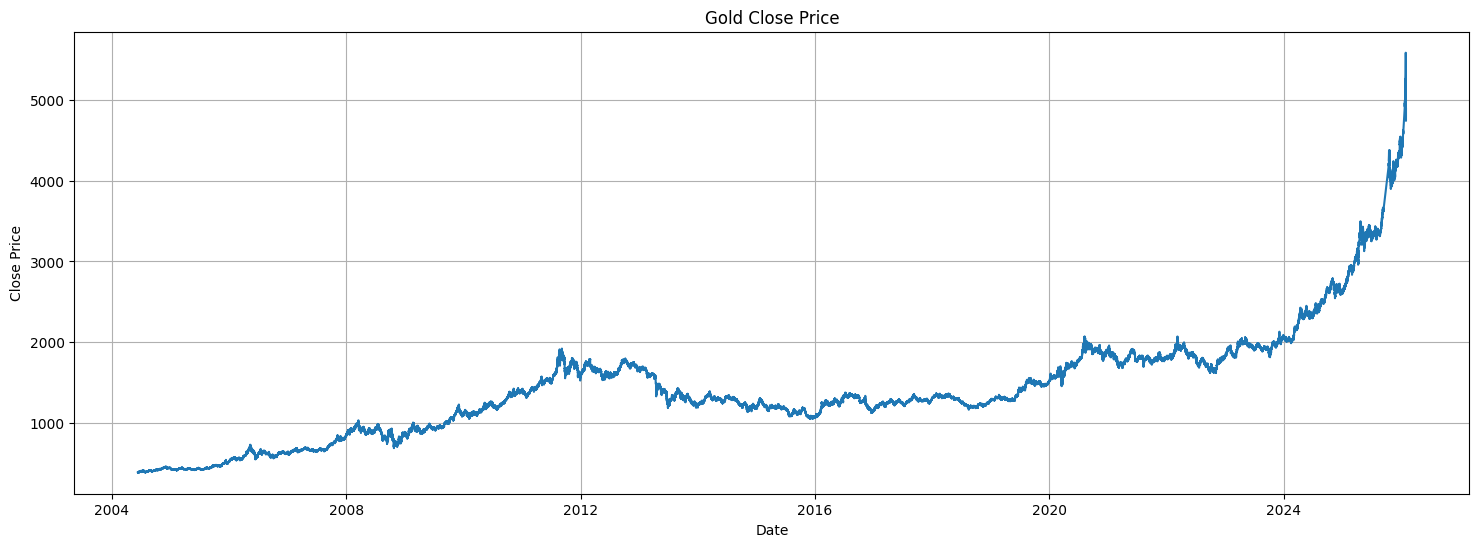

In [18]:
# ==============================
# Close Price Trend
# ==============================

plt.figure(figsize=(18,6))

plt.plot(df["Date"], df["Close"])

plt.title("Gold Close Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.grid(True)

plt.show()


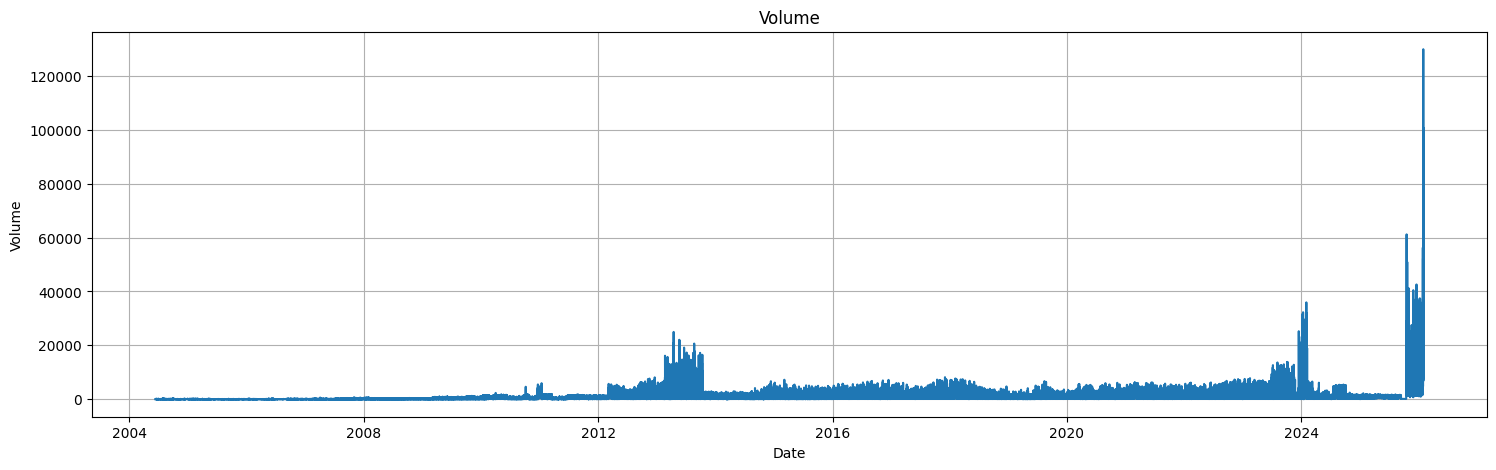

In [19]:
plt.figure(figsize=(18,5))

plt.plot(df["Date"], df["Volume"])

plt.title("Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

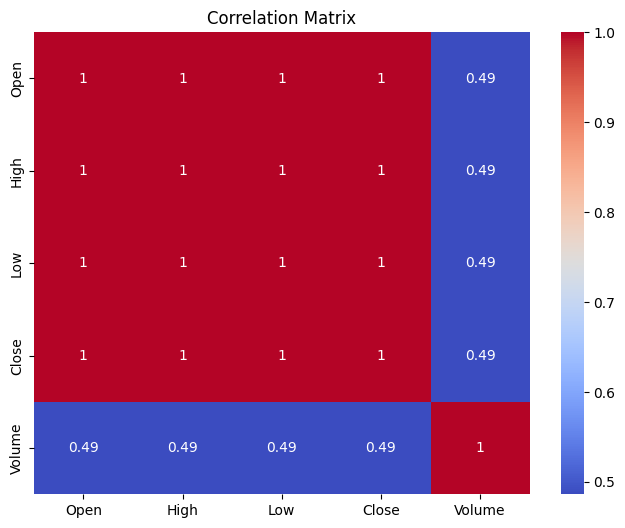

In [20]:
plt.figure(figsize=(8,6))

corr = df[["Open","High","Low","Close","Volume"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

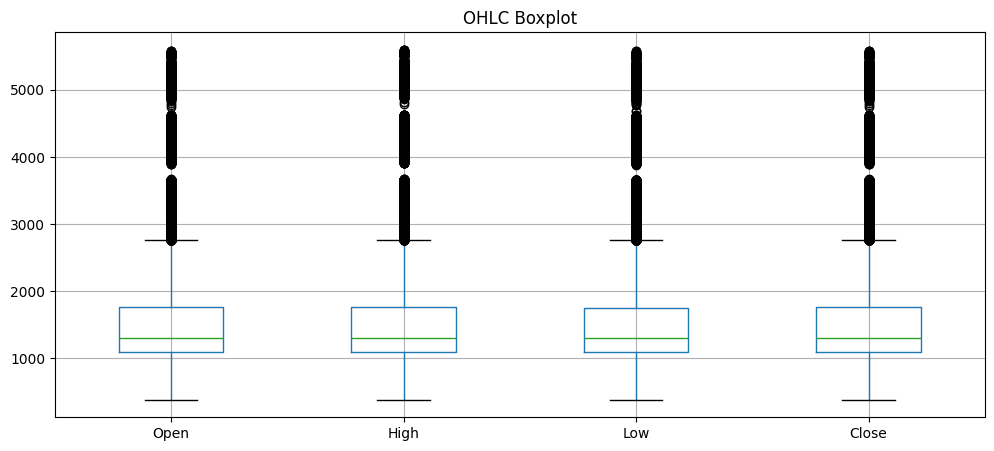

In [21]:
plt.figure(figsize=(12,5))

df[["Open","High","Low","Close"]].boxplot()

plt.title("OHLC Boxplot")

plt.show()

In [22]:
df["Return"] = df["Close"].pct_change()

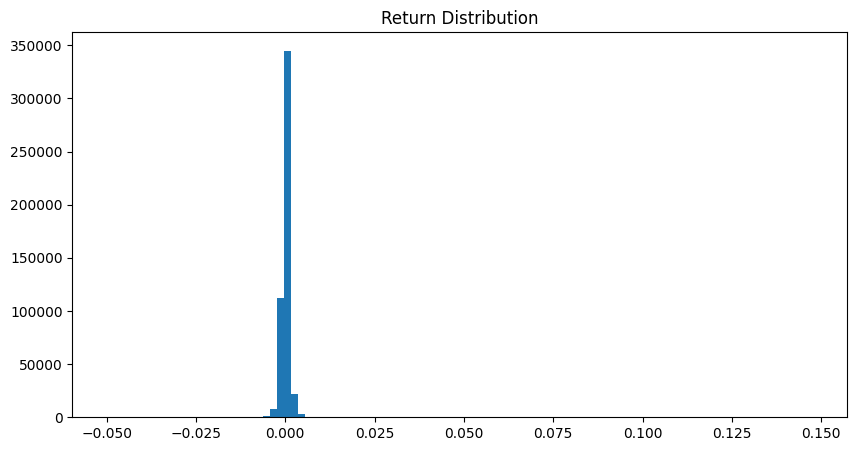

In [23]:
plt.figure(figsize=(10,5))

plt.hist(df["Return"].dropna(), bins=100)

plt.title("Return Distribution")

plt.show()

In [24]:
df["Return"].describe()

,Return
count,494234.000000
mean,0.000006
std,0.001180
min,-0.049731
25%,-0.000431
50%,0.000000
75%,0.000448
max,0.147459


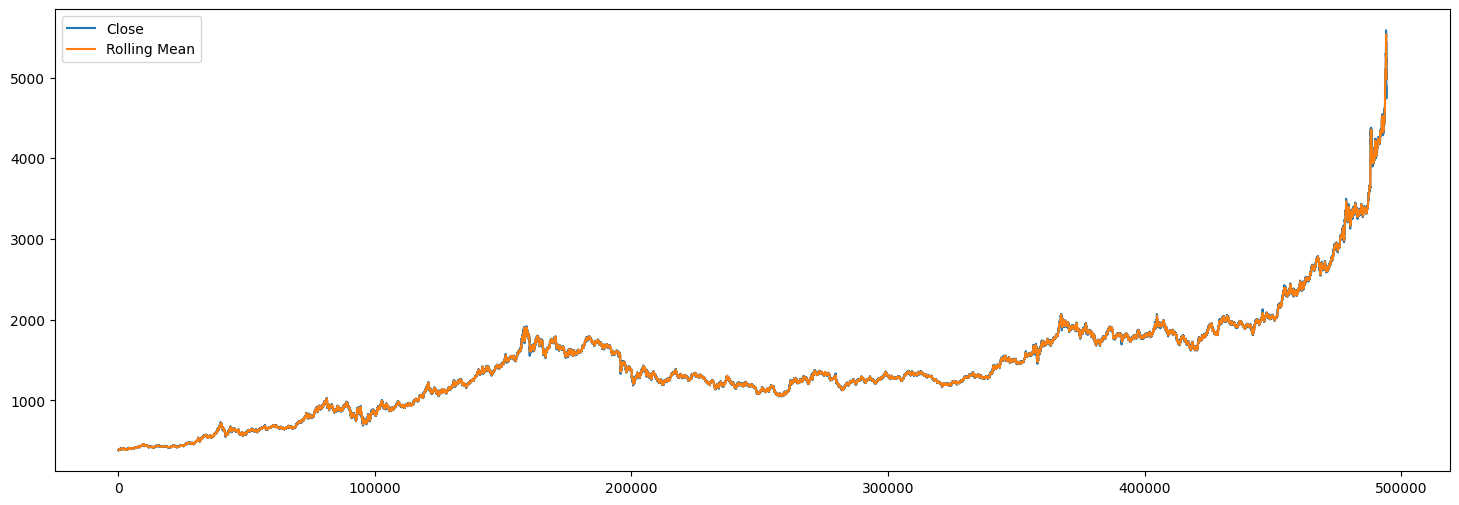

In [25]:
rolling = 50

plt.figure(figsize=(18,6))

plt.plot(df["Close"], label="Close")

plt.plot(
    df["Close"].rolling(rolling).mean(),
    label="Rolling Mean"
)

plt.legend()

plt.show()

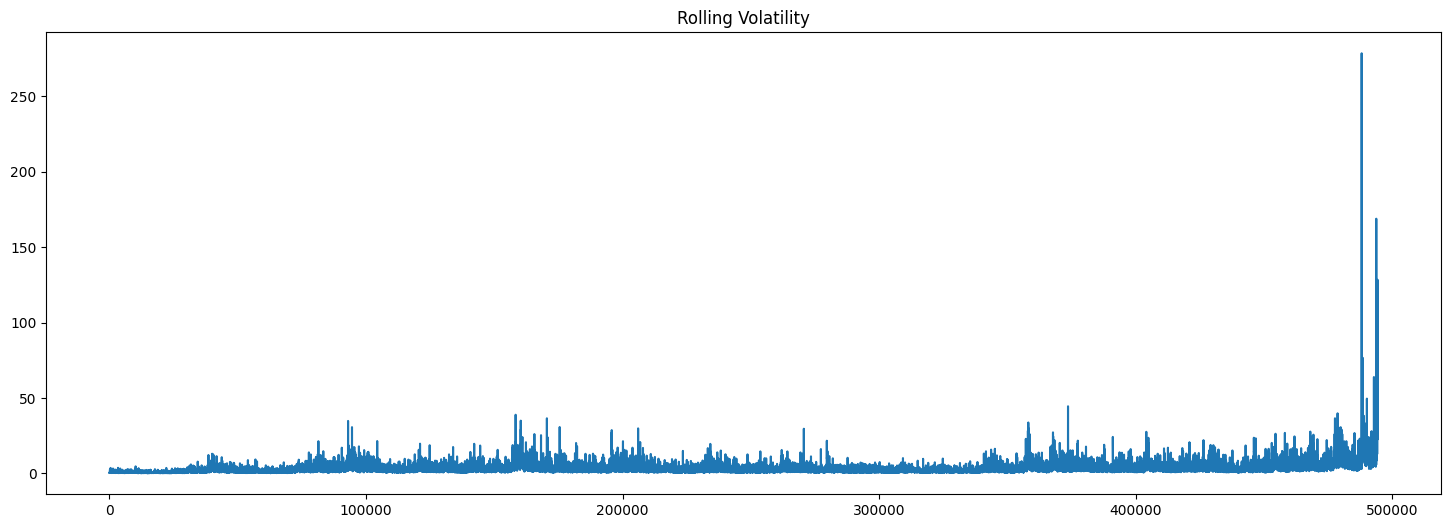

In [26]:
rolling_std = df["Close"].rolling(50).std()

plt.figure(figsize=(18,6))

plt.plot(rolling_std)

plt.title("Rolling Volatility")

plt.show()

In [27]:
np.isinf(df.select_dtypes(include=np.number)).sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Return,0


In [28]:
df["Return"] = df["Return"].fillna(0)

In [29]:
df.to_csv(
    "XAU_15m_processed.csv",
    index=False
)

print("Processed Dataset Saved Successfully ✅")
# Extreme Return Detection

extreme = df[
    (df["Return"] > 0.05) |
    (df["Return"] < -0.05)
]

print("Extreme Return Rows :", len(extreme))

extreme.head()

Processed Dataset Saved Successfully ✅
Extreme Return Rows : 2


,Date,Open,High,Low,Close,Volume,Return
487963,2025-10-15 07:45:00,4178.85,4179.70,4178.66,4179.69,111,0.147459
493662,2026-01-22 18:45:00,4882.23,4883.43,4874.42,4877.95,4397,0.064030


In [30]:
# ==========================================
# Candle Body
# ==========================================

df["Body"] = abs(df["Close"] - df["Open"])

In [31]:
# ==========================================
# Upper Wick
# ==========================================

df["Upper_Wick"] = df["High"] - df[["Open", "Close"]].max(axis=1)

In [32]:
# ==========================================
# Lower Wick
# ==========================================

df["Lower_Wick"] = df[["Open", "Close"]].min(axis=1) - df["Low"]

In [33]:
# ==========================================
# Total Range
# ==========================================

df["Range"] = df["High"] - df["Low"]

In [34]:
# ==========================================
# Candle Direction
# ==========================================

df["Direction"] = np.where(
    df["Close"] > df["Open"],
    "Bullish",
    "Bearish"
)

In [35]:

# ==========================================
# Body Percentage
# ==========================================

df["Body_Percentage"] = np.where(
    df["Range"] == 0,
    0,
    (df["Body"] / df["Range"]) * 100
)

In [36]:
df["Upper_Wick_Percentage"] = np.where(
    df["Range"] == 0,
    0,
    (df["Upper_Wick"] / df["Range"]) * 100
)

In [37]:
df["Lower_Wick_Percentage"] = np.where(
    df["Range"] == 0,
    0,
    (df["Lower_Wick"] / df["Range"]) * 100
)

In [38]:
df["Body_Ratio"] = np.where(
    df["Range"] == 0,
    0,
    df["Body"] / df["Range"]
)

In [39]:
df["Wick_Ratio"] = (
    df["Upper_Wick"] /
    (df["Lower_Wick"] + 1e-10)
)

In [40]:

df["Prev_Direction"] = df["Direction"].shift(1).fillna("None")

In [41]:
df["Target"] = np.where(
    df["Close"].shift(-1) > df["Close"],
    1,
    0
)

In [42]:
df = df.iloc[:-1]

In [43]:
df.head()

,Date,Open,High,Low,Close,Volume,Return,Body,Upper_Wick,Lower_Wick,Range,Direction,Body_Percentage,Upper_Wick_Percentage,Lower_Wick_Percentage,Body_Ratio,Wick_Ratio,Prev_Direction,Target
0,2004-06-11 07:15:00,384.0,384.3,383.8,384.3,12,0.000000,0.3,0.0,0.2,0.5,Bullish,60.0,0.000000,40.000000,0.600,0.000000e+00,None,0
1,2004-06-11 07:30:00,383.8,384.3,383.6,383.8,12,-0.001301,0.0,0.5,0.2,0.7,Bearish,0.0,71.428571,28.571429,0.000,2.500000e+00,Bullish,0
2,2004-06-11 07:45:00,383.3,383.8,383.3,383.8,20,0.000000,0.5,0.0,0.0,0.5,Bullish,100.0,0.000000,0.000000,1.000,0.000000e+00,Bearish,0
3,2004-06-11 08:00:00,383.8,384.1,383.6,383.6,8,-0.000521,0.2,0.3,0.0,0.5,Bearish,40.0,60.000000,0.000000,0.400,3.000000e+09,Bullish,0
4,2004-06-11 08:15:00,383.6,384.3,383.5,383.5,20,-0.000261,0.1,0.7,0.0,0.8,Bearish,12.5,87.500000,0.000000,0.125,7.000000e+09,Bearish,0


In [44]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Return,0
Body,0
Upper_Wick,0
Lower_Wick,0


In [45]:
df.to_csv(
    "XAU_15m_feature_base.csv",
    index=False
)

print("Feature Dataset Saved Successfully ✅")

Feature Dataset Saved Successfully ✅


In [46]:
# ==========================================
# Candlestick Pattern
# ==========================================

df["Pattern"] = "None"

In [47]:
# ==========================================
# Hammer Detection
# ==========================================

hammer = (
    (df["Lower_Wick"] >= 2 * df["Body"]) &
    (df["Upper_Wick"] <= df["Body"] * 0.30) &
    (df["Body"] > 0)
)

df.loc[hammer, "Pattern"] = "Hammer"

print("Hammer :", hammer.sum())

Hammer : 11021


In [48]:
# ==========================================
# Doji Detection
# ==========================================

doji = (
    df["Body_Percentage"] <= 5
)

df.loc[doji, "Pattern"] = "Doji"

print("Doji :", doji.sum())

Doji : 38940


In [49]:
# ==========================================
# Bullish Engulfing
# ==========================================

bullish_engulfing = (

    (df["Direction"] == "Bullish") &

    (df["Prev_Direction"] == "Bearish") &

    (df["Open"] < df["Close"].shift(1)) &

    (df["Close"] > df["Open"].shift(1))

)

df.loc[bullish_engulfing, "Pattern"] = "Bullish Engulfing"

print("Bullish Engulfing :", bullish_engulfing.sum())

Bullish Engulfing : 21060


In [50]:
# ==========================================
# Bearish Engulfing
# ==========================================

bearish_engulfing = (

    (df["Direction"] == "Bearish") &

    (df["Prev_Direction"] == "Bullish") &

    (df["Open"] > df["Close"].shift(1)) &

    (df["Close"] < df["Open"].shift(1))

)

df.loc[bearish_engulfing, "Pattern"] = "Bearish Engulfing"

print("Bearish Engulfing :", bearish_engulfing.sum())

Bearish Engulfing : 18301


In [51]:
df["Pattern"].value_counts()

,count
Pattern,
None,405480
Doji,38909
Bullish Engulfing,21060
Bearish Engulfing,18301
Hammer,10484


In [52]:
df[[
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Pattern"
]].head(20)

,Date,Open,High,Low,Close,Pattern
0,2004-06-11 07:15:00,384.0,384.3,383.8,384.3,None
1,2004-06-11 07:30:00,383.8,384.3,383.6,383.8,Doji
2,2004-06-11 07:45:00,383.3,383.8,383.3,383.8,None
3,2004-06-11 08:00:00,383.8,384.1,383.6,383.6,None
4,2004-06-11 08:15:00,383.6,384.3,383.5,383.5,None
5,2004-06-11 08:30:00,383.3,383.5,383.3,383.5,None
6,2004-06-11 08:45:00,383.3,383.3,383.1,383.1,None
7,2004-06-11 09:00:00,383.1,384.1,383.1,383.6,None
8,2004-06-11 09:15:00,383.8,384.0,382.8,383.0,Bearish Engulfing
9,2004-06-11 09:30:00,383.1,383.3,382.8,383.0,None


In [53]:
# ==========================================================
# PHASE 4 : Candlestick Detection Engine
# ==========================================================

# Create Pattern Columns

patterns = [
    "Hammer",
    "Doji",
    "Bullish_Engulfing",
    "Bearish_Engulfing",
    "Morning_Star",
    "Evening_Star",
    "Harami",
    "Marubozu",
    "Piercing",
    "Dark_Cloud",
    "Three_White_Soldiers",
    "Three_Black_Crows",
    "Shooting_Star",
    "Hanging_Man",
    "Inverted_Hammer",
    "Spinning_Top",
    "Tweezer_Top",
    "Tweezer_Bottom",
    "Three_Inside_Up",
    "Three_Inside_Down",
    "Three_Outside_Up",
    "Three_Outside_Down"
]

for pattern in patterns:
    df[pattern] = 0

print("Pattern Columns Created Successfully ✅")

Pattern Columns Created Successfully ✅


In [54]:
df["Body_Avg"] = df["Body"].rolling(window=14, min_periods=1).mean()
df["Range_Avg"] = df["Range"].rolling(window=14, min_periods=1).mean()

is_long_body = df["Body"] > (1.3 * df["Body_Avg"])
is_short_body = df["Body"] < (0.5 * df["Body_Avg"])
is_doji_body = df["Body"] <= (0.1 * df["Body_Avg"]) # Strict TA-Lib mathematical Doji

In [55]:
hammer = (

    (df["Lower_Wick"] >= 2 * df["Body"]) &

    (df["Upper_Wick"] <= 0.30 * df["Body"]) &

    (df["Body"] > 0)

)

df.loc[hammer, "Hammer"] = 1

print("Hammer :", hammer.sum())

Hammer : 11021


In [56]:
doji = (

    df["Body_Percentage"] <= 5

)

df.loc[doji, "Doji"] = 1

print("Doji :", doji.sum())

Doji : 38940


In [57]:
bearish = (

    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &
    (df["Open"] > df["Close"].shift(1)) &
    (df["Close"] < df["Open"].shift(1))

)

df.loc[bearish, "Bearish_Engulfing"] = 1

print("Bearish Engulfing :", bearish.sum())

Bearish Engulfing : 18301


In [58]:
bullish = (

    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &
    (df["Open"] < df["Close"].shift(1)) &
    (df["Close"] > df["Open"].shift(1))

)

df.loc[bullish, "Bullish_Engulfing"] = 1

print("Bullish Engulfing :", bullish.sum())

Bullish Engulfing : 21060


In [59]:
df[[
    "Hammer",
    "Doji",
    "Bullish_Engulfing",
    "Bearish_Engulfing"
]].sum()

,0
Hammer,11021
Doji,38940
Bullish_Engulfing,21060
Bearish_Engulfing,18301


In [60]:

df[[
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Hammer",
    "Doji",
    "Bullish_Engulfing",
    "Bearish_Engulfing"
]].head(20)

,Date,Open,High,Low,Close,Hammer,Doji,Bullish_Engulfing,Bearish_Engulfing
0,2004-06-11 07:15:00,384.0,384.3,383.8,384.3,0,0,0,0
1,2004-06-11 07:30:00,383.8,384.3,383.6,383.8,0,1,0,0
2,2004-06-11 07:45:00,383.3,383.8,383.3,383.8,0,0,0,0
3,2004-06-11 08:00:00,383.8,384.1,383.6,383.6,0,0,0,0
4,2004-06-11 08:15:00,383.6,384.3,383.5,383.5,0,0,0,0
5,2004-06-11 08:30:00,383.3,383.5,383.3,383.5,0,0,0,0
6,2004-06-11 08:45:00,383.3,383.3,383.1,383.1,0,0,0,0
7,2004-06-11 09:00:00,383.1,384.1,383.1,383.6,0,0,0,0
8,2004-06-11 09:15:00,383.8,384.0,382.8,383.0,0,0,0,1
9,2004-06-11 09:30:00,383.1,383.3,382.8,383.0,0,0,0,0


In [61]:

df.to_csv(
    "XAU_15m_Candlestick.csv",
    index=False
)

print("Candlestick Detection Completed ✅")

Candlestick Detection Completed ✅


In [62]:
# =====================================================
# PHASE 4B-1 : Single Candle Patterns
# =====================================================

single_patterns = [
    "Hammer",
    "Inverted_Hammer",
    "Hanging_Man",
    "Shooting_Star",
    "Doji",
    "Spinning_Top",
    "Marubozu"
]

for pattern in single_patterns:
    if pattern not in df.columns:
        df[pattern] = 0

print("Single Pattern Columns Created Successfully ✅")

Single Pattern Columns Created Successfully ✅


In [63]:
hammer = (

    (df["Lower_Wick"] >= 2 * df["Body"]) &
    (df["Upper_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0)

)

df.loc[hammer, "Hammer"] = 1

print("Hammer :", hammer.sum())

Hammer : 11021


In [64]:
# ==========================================
# Inverted Hammer Detection
# ==========================================

inverted_hammer = (

    (df["Upper_Wick"] >= 2 * df["Body"]) &
    (df["Lower_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0)

)

df.loc[inverted_hammer, "Inverted_Hammer"] = 1

print("Inverted Hammer :", inverted_hammer.sum())

Inverted Hammer : 10503


In [65]:
# ==========================================
# Hanging Man Detection
# ==========================================

hanging_man = (

    (df["Lower_Wick"] >= 2 * df["Body"]) &
    (df["Upper_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0) &
    (df["Direction"].shift(1).fillna("None") == "Bullish")

)

df.loc[hanging_man, "Hanging_Man"] = 1

print("Hanging Man :", hanging_man.sum())

Hanging Man : 5095


In [66]:
# ==========================================
# Shooting Star Detection
# ==========================================

shooting_star = (

    (df["Upper_Wick"] >= 2 * df["Body"]) &
    (df["Lower_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0) &
    (df["Direction"].shift(1).fillna("None") == "Bullish")

)

df.loc[shooting_star, "Shooting_Star"] = 1

print("Shooting Star :", shooting_star.sum())

Shooting Star : 5162


In [67]:
doji = (

    df["Body_Percentage"] <= 5

)

df.loc[doji, "Doji"] = 1

print("Doji :", doji.sum())

Doji : 38940


In [68]:
# ==========================================
# Spinning Top Detection
# ==========================================

spinning_top = (

    (df["Body_Percentage"] >= 10) &
    (df["Body_Percentage"] <= 30) &
    (df["Upper_Wick"] > df["Body"]) &
    (df["Lower_Wick"] > df["Body"])

)

df.loc[spinning_top, "Spinning_Top"] = 1

print("Spinning Top :", spinning_top.sum())

Spinning Top : 49321


In [69]:

# ==========================================
# Marubozu Detection
# ==========================================

marubozu = (

    (df["Body_Percentage"] >= 95)

)

df.loc[marubozu, "Marubozu"] = 1

print("Marubozu :", marubozu.sum())

Marubozu : 22358


In [70]:
summary = df[single_patterns].sum().sort_values(ascending=False)

print(summary)

Spinning_Top       49321
Doji               38940
Marubozu           22358
Hammer             11021
Inverted_Hammer    10503
Shooting_Star       5162
Hanging_Man         5095
dtype: int64


In [71]:
single_patterns = [

    "Hammer",

    "Inverted_Hammer",

    "Hanging_Man",

    "Shooting_Star",

    "Doji",

    "Spinning_Top",

    "Marubozu"

]

df[single_patterns].sum()

,0
Hammer,11021
Inverted_Hammer,10503
Hanging_Man,5095
Shooting_Star,5162
Doji,38940
Spinning_Top,49321
Marubozu,22358


In [72]:
df.loc[
    (df[single_patterns].sum(axis=1) > 0),
    ["Date","Open","High","Low","Close"] + single_patterns
].head(20)

,Date,Open,High,Low,Close,Hammer,Inverted_Hammer,Hanging_Man,Shooting_Star,Doji,Spinning_Top,Marubozu
1,2004-06-11 07:30:00,383.8,384.3,383.6,383.8,0,0,0,0,1,0,0
2,2004-06-11 07:45:00,383.3,383.8,383.3,383.8,0,0,0,0,0,0,1
4,2004-06-11 08:15:00,383.6,384.3,383.5,383.5,0,1,0,0,0,0,0
5,2004-06-11 08:30:00,383.3,383.5,383.3,383.5,0,0,0,0,0,0,1
6,2004-06-11 08:45:00,383.3,383.3,383.1,383.1,0,0,0,0,0,0,1
9,2004-06-11 09:30:00,383.1,383.3,382.8,383.0,0,0,0,0,0,1,0
10,2004-06-11 09:45:00,383.0,383.3,382.8,383.1,0,0,0,0,0,1,0
11,2004-06-11 10:00:00,383.0,383.6,383.0,383.6,0,0,0,0,0,0,1
12,2004-06-11 10:15:00,383.6,383.6,383.6,383.6,0,0,0,0,1,0,0
13,2004-06-11 10:30:00,383.6,383.8,383.5,383.6,0,0,0,0,1,0,0


In [73]:
df.loc[
    (df[single_patterns].sum(axis=1) > 0),

    ["Date","Open","High","Low","Close"] + single_patterns

].head(20)

,Date,Open,High,Low,Close,Hammer,Inverted_Hammer,Hanging_Man,Shooting_Star,Doji,Spinning_Top,Marubozu
1,2004-06-11 07:30:00,383.8,384.3,383.6,383.8,0,0,0,0,1,0,0
2,2004-06-11 07:45:00,383.3,383.8,383.3,383.8,0,0,0,0,0,0,1
4,2004-06-11 08:15:00,383.6,384.3,383.5,383.5,0,1,0,0,0,0,0
5,2004-06-11 08:30:00,383.3,383.5,383.3,383.5,0,0,0,0,0,0,1
6,2004-06-11 08:45:00,383.3,383.3,383.1,383.1,0,0,0,0,0,0,1
9,2004-06-11 09:30:00,383.1,383.3,382.8,383.0,0,0,0,0,0,1,0
10,2004-06-11 09:45:00,383.0,383.3,382.8,383.1,0,0,0,0,0,1,0
11,2004-06-11 10:00:00,383.0,383.6,383.0,383.6,0,0,0,0,0,0,1
12,2004-06-11 10:15:00,383.6,383.6,383.6,383.6,0,0,0,0,1,0,0
13,2004-06-11 10:30:00,383.6,383.8,383.5,383.6,0,0,0,0,1,0,0


In [74]:
# =====================================================
# PHASE 4B-2 : Double Candle Patterns
# =====================================================

double_patterns = [
    "Bullish_Engulfing",
    "Bearish_Engulfing",
    "Bullish_Harami",
    "Bearish_Harami",
    "Piercing_Line",
    "Dark_Cloud_Cover",
    "Tweezer_Top",
    "Tweezer_Bottom"
]

for pattern in double_patterns:
    if pattern not in df.columns:
        df[pattern] = 0

print("Double Pattern Columns Created Successfully ✅")

Double Pattern Columns Created Successfully ✅


In [75]:
bullish_engulfing = (

    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &
    (df["Open"] < df["Close"].shift(1)) &
    (df["Close"] > df["Open"].shift(1))

)

df.loc[bullish_engulfing, "Bullish_Engulfing"] = 1

print("Bullish Engulfing :", bullish_engulfing.sum())

Bullish Engulfing : 21060


In [76]:
bearish_engulfing = (

    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &
    (df["Open"] > df["Close"].shift(1)) &
    (df["Close"] < df["Open"].shift(1))

)

df.loc[bearish_engulfing, "Bearish_Engulfing"] = 1

print("Bearish Engulfing :", bearish_engulfing.sum())

Bearish Engulfing : 18301


In [77]:

bullish_harami = (

    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &

    (df["Open"] > df["Close"].shift(1)) &
    (df["Close"] < df["Open"].shift(1))

)

df.loc[bullish_harami, "Bullish_Harami"] = 1

print("Bullish Harami :", bullish_harami.sum())

Bullish Harami : 20611


In [78]:
bearish_harami = (

    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &

    (df["Open"] < df["Close"].shift(1)) &
    (df["Close"] > df["Open"].shift(1))

)

df.loc[bearish_harami, "Bearish_Harami"] = 1

print("Bearish Harami :", bearish_harami.sum())

Bearish Harami : 22517


In [79]:
piercing = (

    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &

    (df["Open"] < df["Low"].shift(1)) &

    (df["Close"] >
        (
            (df["Open"].shift(1) + df["Close"].shift(1))
            / 2
        )
    )

)

df.loc[piercing, "Piercing_Line"] = 1

print("Piercing Line :", piercing.sum())

Piercing Line : 2775


In [80]:
dark_cloud = (

    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &

    (df["Open"] > df["High"].shift(1)) &

    (df["Close"] <
        (
            (df["Open"].shift(1) + df["Close"].shift(1))
            / 2
        )
    )

)

df.loc[dark_cloud, "Dark_Cloud_Cover"] = 1

print("Dark Cloud Cover :", dark_cloud.sum())

Dark Cloud Cover : 2341


In [81]:
tweezer_top = (

    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &

    (
        abs(
            df["High"] -
            df["High"].shift(1)
        ) <= 0.10
    )

)

df.loc[tweezer_top, "Tweezer_Top"] = 1

print("Tweezer Top :", tweezer_top.sum())

Tweezer Top : 29939


In [82]:
tweezer_bottom = (

    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &

    (
        abs(
            df["Low"] -
            df["Low"].shift(1)
        ) <= 0.10
    )

)

df.loc[tweezer_bottom, "Tweezer_Bottom"] = 1

print("Tweezer Bottom :", tweezer_bottom.sum())

Tweezer Bottom : 28989


In [83]:
summary = df[double_patterns].sum().sort_values(ascending=False)

print(summary)

Tweezer_Top          29939
Tweezer_Bottom       28989
Bearish_Harami       22517
Bullish_Engulfing    21060
Bullish_Harami       20611
Bearish_Engulfing    18301
Piercing_Line         2775
Dark_Cloud_Cover      2341
dtype: int64


In [84]:
df.loc[
    (df[double_patterns].sum(axis=1) > 0),

    ["Date","Open","High","Low","Close"] + double_patterns

].head(20)

,Date,Open,High,Low,Close,Bullish_Engulfing,Bearish_Engulfing,Bullish_Harami,Bearish_Harami,Piercing_Line,Dark_Cloud_Cover,Tweezer_Top,Tweezer_Bottom
1,2004-06-11 07:30:00,383.8,384.3,383.6,383.8,0,0,0,0,0,0,1,0
7,2004-06-11 09:00:00,383.1,384.1,383.1,383.6,0,0,0,0,0,0,0,1
8,2004-06-11 09:15:00,383.8,384.0,382.8,383.0,0,1,0,0,0,0,0,0
10,2004-06-11 09:45:00,383.0,383.3,382.8,383.1,0,0,0,0,0,0,0,1
12,2004-06-11 10:15:00,383.6,383.6,383.6,383.6,0,0,0,0,0,0,1,0
25,2004-06-11 13:30:00,383.6,384.3,383.6,384.3,1,0,0,0,0,0,0,1
26,2004-06-11 13:45:00,384.1,384.3,384.0,384.0,0,0,0,1,0,0,1,0
31,2004-06-11 15:30:00,384.3,384.3,384.1,384.1,0,0,0,0,0,0,1,0
53,2004-06-14 03:30:00,382.5,383.1,382.3,382.6,0,0,0,0,0,0,0,1
54,2004-06-14 03:45:00,382.6,383.1,382.6,382.6,0,0,0,0,0,0,1,0


In [85]:
# 3. Vectorized Multi-Candle Pattern Formulations (Three-Candle Patterns)

# Re-calculate essential candle properties if not already present, for robustness
import numpy as np # Ensure numpy is imported
if "Body" not in df.columns:
    df["Body"] = abs(df["Close"] - df["Open"])
if "Upper_Wick" not in df.columns:
    df["Upper_Wick"] = df["High"] - df[["Open", "Close"]].max(axis=1)
if "Lower_Wick" not in df.columns:
    df["Lower_Wick"] = df[["Open", "Close"]].min(axis=1) - df["Low"]
if "Range" not in df.columns:
    df["Range"] = df["High"] - df["Low"]
if "Direction" not in df.columns:
    df["Direction"] = np.where(
        df["Close"] > df["Open"],
        "Bullish",
        "Bearish"
    )
if "Body_Avg" not in df.columns:
    df["Body_Avg"] = df["Body"].rolling(window=14, min_periods=1).mean()

c0_dir = df["Direction"]
c0_close = df["Close"]
c0_open = df["Open"] # Added this line
c1_dir = df["Direction"].shift(1)
c1_close = df["Close"].shift(1)
c1_open = df["Open"].shift(1)
c2_dir = df["Direction"].shift(2)
c2_open = df["Open"].shift(2)
c2_close = df["Close"].shift(2)
c1_is_short = df["Body"].shift(1) < (df["Body_Avg"].shift(1) * 0.75)

df["Morning_Star"] = np.where((c2_dir == "Bearish") & (df["Body"].shift(2) > df["Body_Avg"].shift(2)) & c1_is_short & (c0_dir == "Bullish") & (c0_close >= (c2_open + c2_close)/2), 1, 0)
df["Evening_Star"] = np.where((c2_dir == "Bullish") & (df["Body"].shift(2) > df["Body_Avg"].shift(2)) & c1_is_short & (c0_dir == "Bearish") & (c0_close <= (c2_open + c2_close)/2), 1, 0)
df["Three_White_Soldiers"] = np.where((c2_dir == "Bullish") & (c1_dir == "Bullish") & (c0_dir == "Bullish") & (c0_close > c1_close) & (c1_close > c2_close) & (c0_open > c1_open) & (c0_open < c1_close) & (c1_open > c2_open) & (c1_open < c2_close) & (df["Upper_Wick"] < 0.2 * df["Body"]) & (df["Upper_Wick"].shift(1) < 0.2 * df["Body"].shift(1)), 1, 0)
df["Three_Black_Crows"] = np.where((c2_dir == "Bearish") & (c1_dir == "Bearish") & (c0_dir == "Bearish") & (c0_close < c1_close) & (c1_close < c2_close) & (c0_open < c1_open) & (c0_open > c1_close) & (c1_open < c2_open) & (c1_open > c2_close) & (df["Lower_Wick"] < 0.2 * df["Body"]) & (df["Lower_Wick"].shift(1) < 0.2 * df["Body"].shift(1)), 1, 0)

In [86]:
import numpy as np # Ensure numpy is imported

# Ensure double-candle pattern columns exist before use
double_pattern_columns_needed = [
    "Bullish_Harami",
    "Bearish_Harami",
    "Bullish_Engulfing",
    "Bearish_Engulfing"
]

for col in double_pattern_columns_needed:
    if col not in df.columns:
        df[col] = 0

# Inside / Outside Formations
df["Three_Inside_Up"] = np.where((df["Bullish_Harami"].shift(1) == 1) & (c0_dir == "Bullish") & (c0_close > c1_close), 1, 0)
df["Three_Inside_Down"] = np.where((df["Bearish_Harami"].shift(1) == 1) & (c0_dir == "Bearish") & (c0_close < c1_close), 1, 0)
df["Three_Outside_Up"] = np.where((df["Bullish_Engulfing"].shift(1) == 1) & (c0_dir == "Bullish") & (c0_close > c1_close), 1, 0)
df["Three_Outside_Down"] = np.where((df["Bearish_Engulfing"].shift(1) == 1) & (c0_dir == "Bearish") & (c0_close < c1_close), 1, 0)

In [87]:
# ============================================================================
# PATTERN VALIDATION & STRUCTURAL CATEGORIZATION ENGINE
# ============================================================================

# Define architectural metadata arrays
pattern_columns = [
    "Hammer", "Inverted_Hammer", "Hanging_Man", "Shooting_Star", "Doji", "Marubozu", "Spinning_Top",
    "Bullish_Engulfing", "Bearish_Engulfing", "Bullish_Harami", "Bearish_Harami", "Piercing_Line",
    "Dark_Cloud_Cover", "Tweezer_Top", "Tweezer_Bottom", "Morning_Star", "Evening_Star",
    "Three_White_Soldiers", "Three_Black_Crows", "Three_Inside_Up", "Three_Inside_Down",
    "Three_Outside_Up", "Three_Outside_Down"
]

# Assign dynamic weights based on systemic significance (Multi-candle & Exogenous setups rank stronger)
pattern_priority = {
    "Three_White_Soldiers": 1, "Three_Black_Crows": 1, "Morning_Star": 2, "Evening_Star": 2,
    "Three_Outside_Up": 3, "Three_Outside_Down": 3, "Three_Inside_Up": 4, "Three_Inside_Down": 4,
    "Bullish_Engulfing": 5, "Bearish_Engulfing": 5, "Piercing_Line": 6, "Dark_Cloud_Cover": 6,
    "Marubozu": 7, "Hammer": 8, "Shooting_Star": 8, "Inverted_Hammer": 9, "Hanging_Man": 9,
    "Tweezer_Top": 10, "Tweezer_Bottom": 10, "Bullish_Harami": 11, "Bearish_Harami": 11,
    "Spinning_Top": 12, "Doji": 13
}

In [88]:
classification_matrix = {
    # Bullish Vector Set
    "Hammer": {"Family": "Bullish", "Type": "Reversal", "Strength": "Medium"},
    "Inverted_Hammer": {"Family": "Bullish", "Type": "Reversal", "Strength": "Weak"},
    "Bullish_Engulfing": {"Family": "Bullish", "Type": "Reversal", "Strength": "Strong"},
    "Bullish_Harami": {"Family": "Bullish", "Type": "Reversal", "Strength": "Medium"},
    "Piercing_Line": {"Family": "Bullish", "Type": "Reversal", "Strength": "Strong"},
    "Tweezer_Bottom": {"Family": "Bullish", "Type": "Reversal", "Strength": "Medium"},
    "Morning_Star": {"Family": "Bullish", "Type": "Reversal", "Strength": "Strong"},
    "Three_White_Soldiers": {"Family": "Bullish", "Type": "Continuation", "Strength": "Strong"},
    "Three_Inside_Up": {"Family": "Bullish", "Type": "Reversal", "Strength": "Strong"},
    "Three_Outside_Up": {"Family": "Bullish", "Type": "Reversal", "Strength": "Strong"},

    # Bearish Vector Set
    "Hanging_Man": {"Family": "Bearish", "Type": "Reversal", "Strength": "Weak"},
    "Shooting_Star": {"Family": "Bearish", "Type": "Reversal", "Strength": "Medium"},
    "Bearish_Engulfing": {"Family": "Bearish", "Type": "Reversal", "Strength": "Strong"},
    "Bearish_Harami": {"Family": "Bearish", "Type": "Reversal", "Strength": "Medium"},
    "Dark_Cloud_Cover": {"Family": "Bearish", "Type": "Reversal", "Strength": "Strong"},
    "Tweezer_Top": {"Family": "Bearish", "Type": "Reversal", "Strength": "Medium"},
    "Evening_Star": {"Family": "Bearish", "Type": "Reversal", "Strength": "Strong"},
    "Three_Black_Crows": {"Family": "Bearish", "Type": "Continuation", "Strength": "Strong"},
    "Three_Inside_Down": {"Family": "Bearish", "Type": "Reversal", "Strength": "Strong"},
    "Three_Outside_Down": {"Family": "Bearish", "Type": "Reversal", "Strength": "Strong"},

    # Neutral/Indecision Vector Set
    "Doji": {"Family": "Neutral", "Type": "Indecision", "Strength": "Medium"},
    "Spinning_Top": {"Family": "Neutral", "Type": "Indecision", "Strength": "Weak"},
    "Marubozu": {"Family": "Neutral", "Type": "Continuation", "Strength": "Medium"} # Dependent on execution direction
}
print("Running Conflict Resolution Engine...")

Running Conflict Resolution Engine...


In [89]:
import numpy as np # Ensure numpy is imported

# pattern_columns and pattern_priority are defined in XzRNz4l862A6 and used here.

# Create a boolean DataFrame of active patterns for each row
matrix_signals = df[pattern_columns].values == 1

# --- Generate Pattern_List and Pattern_Count ---
# Create a list of lists of active pattern names for each row
list_of_active_patterns_names = [
    [pattern_columns[j] for j, is_active in enumerate(row) if is_active]
    for row in matrix_signals
]

df["Pattern_List"] = [",".join(patterns) if patterns else "None" for patterns in list_of_active_patterns_names]
df["Pattern_Count"] = [len(patterns) for patterns in list_of_active_patterns_names]

# --- Determine Primary_Pattern and Secondary_Pattern ---
df["Primary_Pattern"] = "None"
df["Secondary_Pattern"] = "None"

# Populate Primary_Pattern and Secondary_Pattern based on priority
for i, active_patterns_row_names in enumerate(list_of_active_patterns_names):
    if active_patterns_row_names:
        # Sort active patterns by their priority (lower number = higher priority)
        sorted_patterns_by_priority = sorted(active_patterns_row_names, key=lambda p: pattern_priority[p])
        df.at[i, "Primary_Pattern"] = sorted_patterns_by_priority[0]
        if len(sorted_patterns_by_priority) > 1:
            df.at[i, "Secondary_Pattern"] = sorted_patterns_by_priority[1]

# Drop internal baseline variables before saving
# Check if columns exist before dropping
columns_to_drop = [col for col in ["Body_Avg", "Range_Avg"] if col in df.columns]
if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)

# 4. Map Classification Metadata Vectors (now based on Primary_Pattern)
df["Pattern_Family"] = df["Primary_Pattern"].map(lambda x: classification_matrix.get(x, {}).get("Family", "None"))
df["Pattern_Type"] = df["Primary_Pattern"].map(lambda x: classification_matrix.get(x, {}).get("Type", "None"))
df["Pattern_Strength"] = df["Primary_Pattern"].map(lambda x: classification_matrix.get(x, {}).get("Strength", "None"))

# Dynamic adjustment for Directional Marubozus (if Marubozu is Primary_Pattern)
df.loc[(df["Primary_Pattern"] == "Marubozu") & (df["Direction"] == "Bullish"), ["Pattern_Family", "Pattern_Strength"]] = ["Bullish", "Strong"]
df.loc[(df["Primary_Pattern"] == "Marubozu") & (df["Direction"] == "Bearish"), ["Pattern_Family", "Pattern_Strength"]] = ["Bearish", "Strong"]

# Removed 'Validated_Pattern' column as per user request to replace with Primary/Secondary/List.
# If 'Validated_Pattern' was used elsewhere as a direct signal, it should now be replaced by 'Primary_Pattern'.

print("\n--- Validated Detections Post-Conflict Resolution (New Structure) ---")
print(df["Primary_Pattern"].value_counts())
print("\n--- Pattern_Count Distribution ---")
print(df["Pattern_Count"].value_counts().sort_index())
print("\n--- Sample Pattern_List (First 10 non-None) ---")
print(df[df["Pattern_List"] != "None"]["Pattern_List"].head(10).to_string(index=False))

# Save production checkpoint
df.to_csv("XAU_15m_Phase4_Complete.csv", index=False)
print("\nPhase 4 Completed. Production File 'XAU_15m_Phase4_Complete.csv' Saved ✅")


--- Validated Detections Post-Conflict Resolution (New Structure) ---
Primary_Pattern
None                    226004
Spinning_Top             32931
Doji                     28859
Tweezer_Top              23411
Tweezer_Bottom           21241
Bullish_Engulfing        19766
Marubozu                 17437
Bearish_Engulfing        17353
Bearish_Harami           15932
Bullish_Harami           14827
Evening_Star             11193
Morning_Star             10788
Hammer                    9590
Three_Outside_Up          9450
Three_Outside_Down        8382
Three_Inside_Down         7525
Three_Inside_Up           7191
Inverted_Hammer           4661
Shooting_Star             4517
Piercing_Line             1090
Dark_Cloud_Cover          1076
Three_White_Soldiers       527
Three_Black_Crows          483
Name: count, dtype: int64

--- Pattern_Count Distribution ---
Pattern_Count
0    226004
1    196730
2     61607
3      9280
4       608
5         5
Name: count, dtype: int64

--- Sample Pattern_List (

In [90]:
df.to_csv(

    "XAU_15m_Single_Candlestick.csv",

    index=False

)

print("Single Candle Detection Completed ✅")

Single Candle Detection Completed ✅


In [91]:
(df["Upper_Wick"] >= 2 * df["Body"])

,0
0,False
1,True
2,False
3,False
4,True
...,...
494229,False
494230,False
494231,True
494232,False


In [92]:
#  PHASE 5
!pip install ta -q

  Preparing metadata (setup.py) ... done


In [93]:
from ta.trend import EMAIndicator
from ta.trend import ADXIndicator
from ta.trend import MACD

from ta.momentum import RSIIndicator

from ta.volatility import AverageTrueRange

from ta.volume import (
    OnBalanceVolumeIndicator,
    VolumeWeightedAveragePrice
)

print("Technical Indicator Library Loaded Successfully ✅")

Technical Indicator Library Loaded Successfully ✅


In [94]:
ema20 = EMAIndicator(
    close=df["Close"],
    window=20
)

df["EMA20"] = ema20.ema_indicator()

In [95]:
ema50 = EMAIndicator(
    close=df["Close"],
    window=50
)

df["EMA50"] = ema50.ema_indicator()

In [96]:
ema200 = EMAIndicator(
    close=df["Close"],
    window=200
)

df["EMA200"] = ema200.ema_indicator()

In [97]:
rsi = RSIIndicator(
    close=df["Close"],
    window=14
)

df["RSI"] = rsi.rsi()

In [98]:
macd = MACD(
    close=df["Close"]
)

df["MACD"] = macd.macd()

df["MACD_Signal"] = macd.macd_signal()

df["MACD_Histogram"] = macd.macd_diff()

In [99]:
atr = AverageTrueRange(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)

df["ATR"] = atr.average_true_range()

In [100]:
adx = ADXIndicator(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)

df["ADX"] = adx.adx()

In [101]:
obv = OnBalanceVolumeIndicator(
    close=df["Close"],
    volume=df["Volume"]
)

df["OBV"] = obv.on_balance_volume()

In [102]:
vwap = VolumeWeightedAveragePrice(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    volume=df["Volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

In [103]:
df[[
    "EMA20",
    "EMA50",
    "EMA200",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "ATR",
    "ADX",
    "OBV",
    "VWAP"
]].isnull().sum()

,0
EMA20,19
EMA50,49
EMA200,199
RSI,13
MACD,25
MACD_Signal,33
MACD_Histogram,33
ATR,0
ADX,0
OBV,0


In [104]:
indicator_columns = [
    "EMA20",
    "EMA50",
    "EMA200",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "ATR",
    "ADX",
    "OBV",
    "VWAP"
]

df[indicator_columns].head(220)

,EMA20,EMA50,EMA200,RSI,MACD,MACD_Signal,MACD_Histogram,ATR,ADX,OBV,VWAP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,12,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,20,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,12,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,-8,NaN
...,...,...,...,...,...,...,...,...,...,...,...
215,387.036398,385.446301,383.903397,61.053200,0.898159,1.017075,-0.118917,1.106319,41.191538,1130,387.758530
216,387.156741,385.558210,383.947144,61.053200,0.892517,0.992164,-0.099646,1.113010,39.811563,1137,387.740929
217,387.151337,385.618673,383.978516,52.378904,0.782200,0.950171,-0.167971,1.119224,38.530157,1134,387.721097
218,387.260734,385.723823,384.021516,58.698336,0.782581,0.916653,-0.134072,1.124994,37.340280,1138,387.702963


In [105]:
# ==============================
# Indicator Feature List
# ==============================

indicator_features = [
    "EMA20",
    "EMA50",
    "EMA200",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "ATR",
    "ADX",
    "OBV",
    "VWAP"
]

print(indicator_features)

['EMA20', 'EMA50', 'EMA200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'ATR', 'ADX', 'OBV', 'VWAP']


In [106]:
df.to_csv(
    "XAU_15m_with_indicators.csv",
    index=False
)

print("Technical Indicators Added Successfully ✅")

Technical Indicators Added Successfully ✅


In [107]:
# ==============================
# Indicator Feature List
# ==============================

indicator_features = [
    "EMA20",
    "EMA50",
    "EMA200",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "ATR",
    "ADX",
    "OBV",
    "VWAP"
]

print(indicator_features)

['EMA20', 'EMA50', 'EMA200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'ATR', 'ADX', 'OBV', 'VWAP']


In [108]:
pattern_columns = [

    "Hammer",

    "Inverted_Hammer",

    "Hanging_Man",

    "Shooting_Star",

    "Doji",

    "Spinning_Top",

    "Marubozu",

    "Bullish_Engulfing",

    "Bearish_Engulfing",

    "Bullish_Harami",

    "Bearish_Harami",

    "Piercing_Line",

    "Dark_Cloud_Cover",

    "Tweezer_Top",

    "Tweezer_Bottom"

]

print("Total Patterns :", len(pattern_columns))

Total Patterns : 15


In [109]:
import pandas as pd

# Check if df is defined, if not, load the processed DataFrame
if 'df' not in locals():
    try:
        df = pd.read_csv("XAU_15m_Single_Candlestick.csv") # Changed to load Single_Candlestick.csv
        print("DataFrame 'df' loaded from 'XAU_15m_Single_Candlestick.csv' ✅")
    except FileNotFoundError:
        print("Error: 'XAU_15m_Single_Candlestick.csv' not found. Please ensure previous steps are executed. If it's intentional to start from raw data, modify this cell accordingly.")

df["Trade_Result"] = "None"
df["Entry"] = None
df["Stop_Loss"] = None
df["Take_Profit"] = None
df["Profit_Points"] = None
df["Loss_Points"] = None

print("Trade Columns Created Successfully ✅")

Trade Columns Created Successfully ✅


In [110]:
# =====================================================
# PHASE 4B-1 & 4B-2 : Single and Double Candle Patterns (Recalculated after loading from CSV)
# =====================================================

import numpy as np # Ensure numpy is imported

# --- Recalculate essential candle properties after DataFrame reload ---
df["Body"] = abs(df["Close"] - df["Open"])
df["Upper_Wick"] = df["High"] - df[["Open", "Close"]].max(axis=1)
df["Lower_Wick"] = df[["Open", "Close"]].min(axis=1) - df["Low"]
df["Range"] = df["High"] - df["Low"]
df["Direction"] = np.where(
    df["Close"] > df["Open"],
    "Bullish",
    "Bearish"
)
df["Body_Percentage"] = np.where(
    df["Range"] == 0,
    0,
    (df["Body"] / df["Range"]) * 100
)

# --- Single Candle Pattern Initialization and Recalculation ---
single_patterns = [
    "Hammer",
    "Inverted_Hammer",
    "Hanging_Man",
    "Shooting_Star",
    "Doji",
    "Spinning_Top",
    "Marubozu"
]

for pattern in single_patterns:
    if pattern not in df.columns:
        df[pattern] = 0

# Recalculate Hammer
hammer = (
    (df["Lower_Wick"] >= 2 * df["Body"]) &
    (df["Upper_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0)
)
df.loc[hammer, "Hammer"] = 1
print("Hammer :", hammer.sum())

# Recalculate Inverted Hammer
inverted_hammer = (
    (df["Upper_Wick"] >= 2 * df["Body"]) &
    (df["Lower_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0)
)
df.loc[inverted_hammer, "Inverted_Hammer"] = 1
print("Inverted Hammer :", inverted_hammer.sum())

# Recalculate Hanging Man
hanging_man = (
    (df["Lower_Wick"] >= 2 * df["Body"]) &
    (df["Upper_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0) &
    (df["Direction"].shift(1).fillna("None") == "Bullish")
)
df.loc[hanging_man, "Hanging_Man"] = 1
print("Hanging Man :", hanging_man.sum())

# Recalculate Shooting Star
shooting_star = (
    (df["Upper_Wick"] >= 2 * df["Body"]) &
    (df["Lower_Wick"] <= 0.30 * df["Body"]) &
    (df["Body"] > 0) &
    (df["Direction"].shift(1).fillna("None") == "Bullish")
)
df.loc[shooting_star, "Shooting_Star"] = 1
print("Shooting Star :", shooting_star.sum())

# Recalculate Doji
doji = (
    df["Body_Percentage"] <= 5
)
df.loc[doji, "Doji"] = 1
print("Doji :", doji.sum())

# Recalculate Spinning Top
spinning_top = (
    (df["Body_Percentage"] >= 10) &
    (df["Body_Percentage"] <= 30) &
    (df["Upper_Wick"] > df["Body"]) &
    (df["Lower_Wick"] > df["Body"])
)
df.loc[spinning_top, "Spinning_Top"] = 1
print("Spinning Top :", spinning_top.sum())

# Recalculate Marubozu
marubozu = (
    (df["Body_Percentage"] >= 95)
)
df.loc[marubozu, "Marubozu"] = 1
print("Marubozu :", marubozu.sum())

print("Single Pattern Columns Recalculated Successfully ✅")

# --- Double Candle Pattern Initialization and Recalculation ---
double_patterns = [
    "Bullish_Engulfing",
    "Bearish_Engulfing",
    "Bullish_Harami",
    "Bearish_Harami",
    "Piercing_Line",
    "Dark_Cloud_Cover",
    "Tweezer_Top",
    "Tweezer_Bottom"
]

for pattern in double_patterns:
    if pattern not in df.columns:
        df[pattern] = 0

# Recalculate Bullish Engulfing
bullish_engulfing = (
    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &
    (df["Open"] < df["Close"].shift(1)) &
    (df["Close"] > df["Open"].shift(1))
)
df.loc[bullish_engulfing, "Bullish_Engulfing"] = 1
print("Bullish Engulfing :", bullish_engulfing.sum())

# Recalculate Bearish Engulfing
bearish_engulfing = (
    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &
    (df["Open"] > df["Close"].shift(1)) &
    (df["Close"] < df["Open"].shift(1))
)
df.loc[bearish_engulfing, "Bearish_Engulfing"] = 1
print("Bearish Engulfing :", bearish_engulfing.sum())

# Recalculate Bullish Harami
bullish_harami = (
    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &
    (df["Open"] > df["Close"].shift(1)) &
    (df["Close"] < df["Open"].shift(1))
)
df.loc[bullish_harami, "Bullish_Harami"] = 1
print("Bullish Harami :", bullish_harami.sum())

# Recalculate Bearish Harami
bearish_harami = (
    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &
    (df["Open"] < df["Close"].shift(1)) &
    (df["Close"] > df["Open"].shift(1))
)
df.loc[bearish_harami, "Bearish_Harami"] = 1
print("Bearish Harami :", bearish_harami.sum())

# Recalculate Piercing Line
piercing = (
    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &
    (df["Open"] < df["Low"].shift(1)) &
    (df["Close"] > ((df["Open"].shift(1) + df["Close"].shift(1)) / 2))
)
df.loc[piercing, "Piercing_Line"] = 1
print("Piercing Line :", piercing.sum())

# Recalculate Dark Cloud Cover
dark_cloud = (
    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &
    (df["Open"] > df["High"].shift(1)) &
    (df["Close"] < ((df["Open"].shift(1) + df["Close"].shift(1)) / 2))
)
df.loc[dark_cloud, "Dark_Cloud_Cover"] = 1
print("Dark Cloud Cover :", dark_cloud.sum())

# Recalculate Tweezer Top
tweezer_top = (
    (df["Direction"] == "Bearish") &
    (df["Direction"].shift(1).fillna("None") == "Bullish") &
    (abs(df["High"] - df["High"].shift(1)) <= 0.10)
)
df.loc[tweezer_top, "Tweezer_Top"] = 1
print("Tweezer Top :", tweezer_top.sum())

# Recalculate Tweezer Bottom
tweezer_bottom = (
    (df["Direction"] == "Bullish") &
    (df["Direction"].shift(1).fillna("None") == "Bearish") &
    (abs(df["Low"] - df["Low"].shift(1)) <= 0.10)
)
df.loc[tweezer_bottom, "Tweezer_Bottom"] = 1
print("Tweezer Bottom :", tweezer_bottom.sum())

print("Double Pattern Columns Recalculated Successfully ✅")

Hammer : 11021
Inverted Hammer : 10503
Hanging Man : 5095
Shooting Star : 5162
Doji : 38940
Spinning Top : 49321
Marubozu : 22358
Single Pattern Columns Recalculated Successfully ✅
Bullish Engulfing : 21060
Bearish Engulfing : 18301
Bullish Harami : 20611
Bearish Harami : 22517
Piercing Line : 2775
Dark Cloud Cover : 2341
Tweezer Top : 29939
Tweezer Bottom : 28989
Double Pattern Columns Recalculated Successfully ✅


In [111]:
# ============================================================================
# PHASE 6: HISTORICAL STATISTICS ENGINE
# Production-Quality Vectorized Performance Evaluation Matrix
# ============================================================================

import numpy as np
import pandas as pd

print("Initiating High-Performance Historical Statistics Engine...")

# --- 1. Forward-Looking Horizon Generation ---
# Shift prices backward to simulate a 4-candle forward lookahead matrix
for i in range(1, 5):
    df[f"Fwd_High_+{i}"] = df["High"].shift(-i)
    df[f"Fwd_Low_+{i}"] = df["Low"].shift(-i)
    df[f"Fwd_Close_+{i}"] = df["Close"].shift(-i)

Initiating High-Performance Historical Statistics Engine...


In [112]:
# Baseline Execution Rules
df["Entry_Price"] = df["Open"].shift(-1)  # Next candle open execution

# --- 2. Adaptive Structural Risk Boundaries ---
# Bullish Pattern: Stop Loss = Pattern Low | Target = Entry + (2 * Risk)
# Bearish Pattern: Stop Loss = Pattern High | Target = Entry - (2 * Risk)
df["Bullish_SL"] = df["Low"]
df["Bullish_Risk"] = np.maximum(df["Entry_Price"] - df["Bullish_SL"], 1e-4)
df["Bullish_TP"] = df["Entry_Price"] + (2.0 * df["Bullish_Risk"])

df["Bearish_SL"] = df["High"]
df["Bearish_Risk"] = np.maximum(df["Bearish_SL"] - df["Entry_Price"], 1e-4)
df["Bearish_TP"] = df["Entry_Price"] - (2.0 * df["Bearish_Risk"])

In [113]:
# --- 3. High-Performance Vectorized Trade Tracking ---
# Multi-period forward boundary conditions for validation
h1, h2, h3, h4 = df["Fwd_High_+1"], df["Fwd_High_+2"], df["Fwd_High_+3"], df["Fwd_High_+4"]
l1, l2, l3, l4 = df["Fwd_Low_+1"], df["Fwd_Low_+2"], df["Fwd_Low_+3"], df["Fwd_Low_+4"]
c4 = df["Fwd_Close_+4"]

# --- Bullish Logic Tracking ---
bull_hit_sl1 = l1 <= df["Bullish_SL"]
bull_hit_tp1 = h1 >= df["Bullish_TP"]
bull_hit_sl2 = (~bull_hit_tp1) & (l2 <= df["Bullish_SL"])
bull_hit_tp2 = (~bull_hit_sl1) & (h2 >= df["Bullish_TP"])
bull_hit_sl3 = (~bull_hit_tp1) & (~bull_hit_tp2) & (l3 <= df["Bullish_SL"])
bull_hit_tp3 = (~bull_hit_sl1) & (~bull_hit_sl2) & (h3 >= df["Bullish_TP"])
bull_hit_sl4 = (~bull_hit_tp1) & (~bull_hit_tp2) & (~bull_hit_tp3) & (l4 <= df["Bullish_SL"])
bull_hit_tp4 = (~bull_hit_sl1) & (~bull_hit_sl2) & (~bull_hit_sl3) & (h4 >= df["Bullish_TP"])
bull_is_win = bull_hit_tp1 | bull_hit_tp2 | bull_hit_tp3 | bull_hit_tp4
bull_is_loss = (~bull_is_win) & (bull_hit_sl1 | bull_hit_sl2 | bull_hit_sl3 | bull_hit_sl4)
bull_is_expired = (~bull_is_win) & (~bull_is_loss)

In [114]:
# --- Bearish Logic Tracking ---
bear_hit_sl1 = h1 >= df["Bearish_SL"]
bear_hit_tp1 = l1 <= df["Bearish_TP"]
bear_hit_sl2 = (~bear_hit_tp1) & (h2 >= df["Bearish_SL"])
bear_hit_tp2 = (~bear_hit_sl1) & (l2 <= df["Bearish_TP"])
bear_hit_sl3 = (~bear_hit_tp1) & (~bear_hit_tp2) & (h3 >= df["Bearish_SL"])
bear_hit_tp3 = (~bear_hit_sl1) & (~bear_hit_sl2) & (l3 <= df["Bearish_TP"])
bear_hit_sl4 = (~bear_hit_tp1) & (~bear_hit_tp2) & (~bear_hit_tp3) & (h4 >= df["Bearish_SL"])
bear_hit_tp4 = (~bear_hit_sl1) & (~bear_hit_sl2) & (~bear_hit_sl3) & (l4 <= df["Bearish_TP"])

bear_is_win = bear_hit_tp1 | bear_hit_tp2 | bear_hit_tp3 | bear_hit_tp4
bear_is_loss = (~bear_is_win) & (bear_hit_sl1 | bear_hit_sl2 | bear_hit_sl3 | bear_hit_sl4)
bear_is_expired = (~bear_is_win) & (~bear_is_loss)

In [115]:
# --- 4. Synthesize Dynamic Outcome Matrices ---
df["Trade_Outcome"] = "None"
df["Trade_Profit_Pct"] = 0.0

# Apply Bullish Filters
bull_mask = df["Pattern_Family"] == "Bullish"
df.loc[bull_mask & bull_is_win, "Trade_Outcome"] = "Win"
df.loc[bull_mask & bull_is_loss, "Trade_Outcome"] = "Loss"
df.loc[bull_mask & bull_is_expired, "Trade_Outcome"] = "Expired"

df.loc[bull_mask & bull_is_win, "Trade_Profit_Pct"] = (df["Bullish_TP"] - df["Entry_Price"]) / df["Entry_Price"] * 100
df.loc[bull_mask & bull_is_loss, "Trade_Profit_Pct"] = (df["Bullish_SL"] - df["Entry_Price"]) / df["Entry_Price"] * 100
df.loc[bull_mask & bull_is_expired, "Trade_Profit_Pct"] = (c4 - df["Entry_Price"]) / df["Entry_Price"] * 100

# Apply Bearish Filters
bear_mask = df["Pattern_Family"] == "Bearish"
df.loc[bear_mask & bear_is_win, "Trade_Outcome"] = "Win"
df.loc[bear_mask & bear_is_loss, "Trade_Outcome"] = "Loss"
df.loc[bear_mask & bear_is_expired, "Trade_Outcome"] = "Expired"

df.loc[bear_mask & bear_is_win, "Trade_Profit_Pct"] = (df["Entry_Price"] - df["Bearish_TP"]) / df["Entry_Price"] * 100
df.loc[bear_mask & bear_is_loss, "Trade_Profit_Pct"] = (df["Entry_Price"] - df["Bearish_SL"]) / df["Entry_Price"] * 100
df.loc[bear_mask & bear_is_expired, "Trade_Profit_Pct"] = (df["Entry_Price"] - c4) / df["Entry_Price"] * 100

In [116]:
# --- 5. Clean Matrix Footprints & Standardize Features ---
fwd_cols = [f"Fwd_{param}_{i}" for param in ["High", "Low", "Close"] for i in range(1, 5)]
internal_risk_cols = ["Entry_Price", "Bullish_SL", "Bullish_Risk", "Bullish_TP", "Bearish_SL", "Bearish_Risk", "Bearish_TP"]
df.drop(columns=fwd_cols + internal_risk_cols, inplace=True, errors="ignore")

In [117]:
# --- 6. Historical Statistics Aggregation Engine ---
print("\nCalculating Institutional Performance Profiles per Pattern...")

stats_summary = []

# Use the comprehensive list of pattern columns for individual pattern statistics
# `pattern_columns` is defined in XzRNz4l862A6 and contains all relevant patterns.
active_patterns_for_stats = [p for p in pattern_columns if p in df.columns]

for pattern in active_patterns_for_stats:
    # Filter the DataFrame for rows where THIS SPECIFIC pattern is detected (binary flag == 1)
    pattern_df = df[df[pattern] == 1].copy() # .copy() to avoid SettingWithCopyWarning

    total_trades = len(pattern_df)

    if total_trades == 0:
        continue

    wins = len(pattern_df[pattern_df["Trade_Outcome"] == "Win"])
    losses = len(pattern_df[pattern_df["Trade_Outcome"] == "Loss"])
    expired = len(pattern_df[pattern_df["Trade_Outcome"] == "Expired"])

    win_rate = (wins / total_trades) * 100
    loss_rate = (losses / total_trades) * 100

    avg_profit = pattern_df[pattern_df["Trade_Outcome"] == "Win"]["Trade_Profit_Pct"].mean() if wins > 0 else 0.0
    avg_loss = pattern_df[pattern_df["Trade_Outcome"] == "Loss"]["Trade_Profit_Pct"].mean() if losses > 0 else 0.0

    total_win_val = pattern_df[pattern_df["Trade_Profit_Pct"] > 0]["Trade_Profit_Pct"].sum()
    total_loss_val = abs(pattern_df[pattern_df["Trade_Profit_Pct"] < 0]["Trade_Profit_Pct"].sum())
    profit_factor = total_win_val / total_loss_val if total_loss_val > 0 else total_win_val # Handle division by zero

    # Calculate Drawdown profile safely via cumsum
    cum_returns = pattern_df["Trade_Profit_Pct"].cumsum()
    running_max = cum_returns.cummax()
    drawdowns = running_max - cum_returns
    max_dd = drawdowns.max() if not drawdowns.empty else 0.0 # Handle empty series for max_dd

    # Mathematical Expected Value
    ev = (win_rate / 100 * avg_profit) + (loss_rate / 100 * avg_loss)

    stats_summary.append({
        "Pattern": pattern, "Trades": total_trades, "Wins": wins, "Losses": losses, "Expired": expired,
        "Win_Rate%": round(win_rate, 2), "Profit_Factor": round(profit_factor, 2), "Max_DD%": round(max_dd, 2), "EV": round(ev, 4)
    })

# Format and Display Summary
stats_df = pd.DataFrame(stats_summary).sort_values(by="Profit_Factor", ascending=False)
print("\n" + "="*80 + "\nHISTORICAL STATISTICS PROFILE MATRIX (Per Individual Pattern)\n" + "="*80)
print(stats_df.to_string(index=False))
print("="*80)

# The row-level 'Hist_Win_Rate', 'Hist_Profit_Factor', 'Hist_Expected_Value' columns
# are no longer directly populated here for a single 'Validated_Pattern'.
# If these are needed as features for the AI model on a row-by-row basis,
# a separate mapping step should be performed after the 'Primary_Pattern' has been determined.
# For now, the aggregated `stats_df` provides the requested historical statistics for all patterns.

# Checkpoint verification
df.to_csv("XAU_15m_Phase6_Complete.csv", index=False)
print("\nPhase 6 Engine Complete. Production File 'XAU_15m_Phase6_Complete.csv' Saved ✅")


Calculating Institutional Performance Profiles per Pattern...

HISTORICAL STATISTICS PROFILE MATRIX (Per Individual Pattern)
          Pattern  Trades  Wins  Losses  Expired  Win_Rate%  Profit_Factor  Max_DD%      EV
     Spinning_Top   49321  5453    9206     1731      11.06           1.14     8.35  0.0002
   Bullish_Harami   20611  6066   10653     3892      29.43           1.14    10.18 -0.0043
  Inverted_Hammer   10503  4460    4478     1565      42.46           1.13    11.89 -0.0026
   Bearish_Harami   22517  7023   11882     3612      31.19           1.08    17.83 -0.0035
             Doji   38940  4209    5118      754      10.81           1.08    30.99 -0.0001
    Shooting_Star    5162  1287    2531     1344      24.93           1.05     7.74 -0.0101
      Tweezer_Top   29939  8908   15034     5997      29.75           1.03    55.24 -0.0042
   Tweezer_Bottom   28989  8141   14405     6443      28.08           1.02    35.48 -0.0060
    Piercing_Line    2775   523    1179     10

### Diagnostic Information

In [118]:
# 1. List of all dataframe columns
print("\n--- 1. All DataFrame Columns ---")
print(df.columns.tolist())


--- 1. All DataFrame Columns ---
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Body', 'Upper_Wick', 'Lower_Wick', 'Range', 'Direction', 'Body_Percentage', 'Upper_Wick_Percentage', 'Lower_Wick_Percentage', 'Body_Ratio', 'Wick_Ratio', 'Prev_Direction', 'Target', 'Pattern', 'Hammer', 'Doji', 'Bullish_Engulfing', 'Bearish_Engulfing', 'Morning_Star', 'Evening_Star', 'Harami', 'Marubozu', 'Piercing', 'Dark_Cloud', 'Three_White_Soldiers', 'Three_Black_Crows', 'Shooting_Star', 'Hanging_Man', 'Inverted_Hammer', 'Spinning_Top', 'Tweezer_Top', 'Tweezer_Bottom', 'Three_Inside_Up', 'Three_Inside_Down', 'Three_Outside_Up', 'Three_Outside_Down', 'Bullish_Harami', 'Bearish_Harami', 'Piercing_Line', 'Dark_Cloud_Cover', 'Pattern_List', 'Pattern_Count', 'Primary_Pattern', 'Secondary_Pattern', 'Pattern_Family', 'Pattern_Type', 'Pattern_Strength', 'EMA20', 'EMA50', 'EMA200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'ATR', 'ADX', 'OBV', 'VWAP', 'Trade_Result', 'Entry', 'Stop_Loss', '

In [119]:
# 2. Count of every candlestick pattern column
print("\n--- 2. Count of Every Candlestick Pattern Column (Raw Detections) ---")
# Combine all known pattern lists to ensure we cover everything, if available
all_pattern_columns = [
    "Hammer", "Inverted_Hammer", "Hanging_Man", "Shooting_Star", "Doji", "Marubozu", "Spinning_Top",
    "Bullish_Engulfing", "Bearish_Engulfing", "Bullish_Harami", "Bearish_Harami", "Piercing_Line",
    "Dark_Cloud_Cover", "Tweezer_Top", "Tweezer_Bottom", "Morning_Star", "Evening_Star",
    "Three_White_Soldiers", "Three_Black_Crows", "Three_Inside_Up", "Three_Inside_Down",
    "Three_Outside_Up", "Three_Outside_Down"
]

for pattern in all_pattern_columns:
    if pattern in df.columns:
        print(f"{pattern}: {df[pattern].sum()}")
    else:
        print(f"{pattern}: Not Found in DataFrame")


--- 2. Count of Every Candlestick Pattern Column (Raw Detections) ---
Hammer: 11021
Inverted_Hammer: 10503
Hanging_Man: 5095
Shooting_Star: 5162
Doji: 38940
Marubozu: 22358
Spinning_Top: 49321
Bullish_Engulfing: 21060
Bearish_Engulfing: 18301
Bullish_Harami: 20611
Bearish_Harami: 22517
Piercing_Line: 2775
Dark_Cloud_Cover: 2341
Tweezer_Top: 29939
Tweezer_Bottom: 28989
Morning_Star: 10788
Evening_Star: 11193
Three_White_Soldiers: 527
Three_Black_Crows: 483
Three_Inside_Up: 9894
Three_Inside_Down: 10591
Three_Outside_Up: 9450
Three_Outside_Down: 8382


In [120]:
# 3. pattern_columns list used by Phase 6 (from cell XzRNz4l862A6)
print("\n--- 3. `pattern_columns` list (Defined in Cell `XzRNz4l862A6`) ---")
print(pattern_columns)


--- 3. `pattern_columns` list (Defined in Cell `XzRNz4l862A6`) ---
['Hammer', 'Inverted_Hammer', 'Hanging_Man', 'Shooting_Star', 'Doji', 'Spinning_Top', 'Marubozu', 'Bullish_Engulfing', 'Bearish_Engulfing', 'Bullish_Harami', 'Bearish_Harami', 'Piercing_Line', 'Dark_Cloud_Cover', 'Tweezer_Top', 'Tweezer_Bottom']


In [121]:
# 4. Unique values of Primary_Pattern and their counts
print("\n--- 4. Unique Values of `Primary_Pattern` and their Counts ---")
print(df["Primary_Pattern"].value_counts())


--- 4. Unique Values of `Primary_Pattern` and their Counts ---
Primary_Pattern
None                    226004
Spinning_Top             32931
Doji                     28859
Tweezer_Top              23411
Tweezer_Bottom           21241
Bullish_Engulfing        19766
Marubozu                 17437
Bearish_Engulfing        17353
Bearish_Harami           15932
Bullish_Harami           14827
Evening_Star             11193
Morning_Star             10788
Hammer                    9590
Three_Outside_Up          9450
Three_Outside_Down        8382
Three_Inside_Down         7525
Three_Inside_Up           7191
Inverted_Hammer           4661
Shooting_Star             4517
Piercing_Line             1090
Dark_Cloud_Cover          1076
Three_White_Soldiers       527
Three_Black_Crows          483
Name: count, dtype: int64


In [122]:
# 5. Pattern Priority table (from cell XzRNz4l862A6)
print("\n--- 5. Pattern Priority Table (Defined in Cell `XzRNz4l862A6`) ---")
for pattern, priority in pattern_priority.items():
    print(f"{pattern}: {priority}")


--- 5. Pattern Priority Table (Defined in Cell `XzRNz4l862A6`) ---
Three_White_Soldiers: 1
Three_Black_Crows: 1
Morning_Star: 2
Evening_Star: 2
Three_Outside_Up: 3
Three_Outside_Down: 3
Three_Inside_Up: 4
Three_Inside_Down: 4
Bullish_Engulfing: 5
Bearish_Engulfing: 5
Piercing_Line: 6
Dark_Cloud_Cover: 6
Marubozu: 7
Hammer: 8
Shooting_Star: 8
Inverted_Hammer: 9
Hanging_Man: 9
Tweezer_Top: 10
Tweezer_Bottom: 10
Bullish_Harami: 11
Bearish_Harami: 11
Spinning_Top: 12
Doji: 13


In [123]:
# 6. Total number of patterns detected before validation (total rows where at least one pattern flag is 1)
print("\n--- 6. Total Number of Patterns Detected Before Validation (Rows with at least one pattern) ---")

# Summing rows where any of the original pattern columns are 1
# Use the `all_pattern_columns` defined previously, filtering for columns that actually exist in df
existing_pattern_cols_for_sum = [col for col in all_pattern_columns if col in df.columns]
if existing_pattern_cols_for_sum:
    total_before_validation = df[existing_pattern_cols_for_sum].sum(axis=1).astype(bool).sum()
    print(f"Total patterns detected before validation: {total_before_validation}")
else:
    print("No pattern columns found in DataFrame to sum for pre-validation detection count.")


--- 6. Total Number of Patterns Detected Before Validation (Rows with at least one pattern) ---
Total patterns detected before validation: 268230


In [124]:
total_after_validation = df[df["Primary_Pattern"] != "None"].shape[0]
print(f"Total patterns detected after validation: {total_after_validation}")

Total patterns detected after validation: 268230


In [126]:
# ==============================================================================
# 🥇 PHASE 6: MATRIX LOOKBACK SLICING ENGINE (15M LOCKED PROFILE)
# ==============================================================================
import numpy as np
import pandas as pd

print("==========================================================")
print("⚙️ INJECTING HIGH-PERFORMANCE MATRIX LOOKBACK ENGINE")
print("==========================================================")

def generate_lookback_matrix_slices(dataframe, feature_cols, lookback_value):
    """
    Slices chronological standard feature tables into flattened historical
    context rows matching guide sir's lookback matrix rules.
    """
    X_matrix = []
    y_matrix = []

    # Fast extraction into numpy continuous arrays
    raw_features = dataframe[feature_cols].values
    raw_targets = dataframe['Target_Cls'].values

    # Chronological sliding window matrix formulation
    # Target index corresponds to index 'i' (Next Completed Candle)
    for i in range(lookback_value, len(dataframe)):
        # Collect window sequence block slice (i-lookback upto i)
        window_block = raw_features[i - lookback_value:i]

        # Flatten the sequence matrices into a strict single tabular feature vector
        flattened_vector = window_block.flatten()

        X_matrix.append(flattened_vector)
        y_matrix.append(raw_targets[i])

    return np.array(X_matrix), np.array(y_matrix)

# ------------------------------------------------------------------------------
# STEP 1: Feature Columns Universe Synchronization
# ------------------------------------------------------------------------------
# Mapping all active feature signatures available from modified Phase 3 & 4
active_features_list = [
    "EMA20", "EMA50", "EMA200", "RSI", "MACD", "MACD_Signal", "MACD_Histogram",
    "ATR", "ADX", "OBV", "VWAP", "Body_to_Range", "Upper_Wick_Ratio", "Lower_Wick_Ratio",
    "Hammer", "Inverted_Hammer", "Hanging_Man", "Shooting_Star", "Doji", "Spinning_Top", "Marubozu",
    "Bullish_Engulfing", "Bearish_Engulfing", "Bullish_Harami", "Bearish_Harami"
]

# Quick filter safety validation to match exact runtime availability
active_features_list = [col for col in active_features_list if col in df.columns]

print(f"✓ Lookback Slicer configured with {len(active_features_list)} active column footprints.")
print("✓ Target Sync Strategy: Pure 1-candle horizon classification.")
print("==========================================================")
print("✅ Phase 6 Slicing Logic Ready. Awaiting Optimization Triggers.")
print("==========================================================")

⚙️ INJECTING HIGH-PERFORMANCE MATRIX LOOKBACK ENGINE
✓ Lookback Slicer configured with 22 active column footprints.
✓ Target Sync Strategy: Pure 1-candle horizon classification.
✅ Phase 6 Slicing Logic Ready. Awaiting Optimization Triggers.


In [127]:
# ============================================================================
# PHASE 7: ADVANCED FEATURE ENGINEERING
# Production-Quality Non-Linear Alpha Features for Deep Learning
# ============================================================================

import numpy as np
import pandas as pd

print("Initiating Advanced Feature Engineering Pipeline...")

# --- 1. Multi-Period Volatility & Normalization Paths ---
# Parkinson Volatility captures intra-bar variance using High/Low ranges
df["Parkinson_Vol_14"] = np.sqrt((1.0 / (4.0 * np.log(2.0))) * ((np.log(df["High"] / df["Low"])) ** 2).rolling(window=14).mean())
df["Parkinson_Vol_50"] = np.sqrt((1.0 / (4.0 * np.log(2.0))) * ((np.log(df["High"] / df["Low"])) ** 2).rolling(window=50).mean())

# Normalized Real Body and ATR Ratios
df["Body_to_ATR_14"] = np.where(df["ATR"] == 0, 0, df["Body"] / df["ATR"])
df["Range_to_ATR_14"] = np.where(df["ATR"] == 0, 0, df["Range"] / df["ATR"])

# --- 2. Rolling Distribution Metrics (Fat-Tail & Skew Indicators) ---
# Captures structural shifts in momentum over short and medium horizons
df["Return_Skew_14"] = df["Return"].rolling(window=14).skew()
df["Return_Kurt_14"] = df["Return"].rolling(window=14).kurt()
df["Return_Skew_50"] = df["Return"].rolling(window=50).skew()
df["Return_Kurt_50"] = df["Return"].rolling(window=50).kurt()

# --- 3. Geometric Convergence & Distance Vectors ---
# Quantifies distance from price structural anchors to prevent scale leakage
df["Dist_EMA20"] = (df["Close"] - df["EMA20"]) / df["EMA20"] * 100
df["Dist_EMA50"] = (df["Close"] - df["EMA50"]) / df["EMA50"] * 100
df["Dist_EMA200"] = (df["Close"] - df["EMA200"]) / df["EMA200"] * 100
df["EMA_Spread_Short_Medium"] = (df["EMA20"] - df["EMA50"]) / df["EMA50"] * 100

# --- 4. Advanced Interaction Features ---
# Volume-Price Momentum Coupling
df["Volume_Price_ZScore"] = (df["Volume"] * df["Return"] - (df["Volume"] * df["Return"]).rolling(window=14).mean()) / ((df["Volume"] * df["Return"]).rolling(window=14).std() + 1e-8)

# RSI Extremes Tracking
df["RSI_Overbought_Dev"] = np.maximum(0.0, df["RSI"] - 70.0)
df["RSI_Oversold_Dev"] = np.maximum(0.0, 30.0 - df["RSI"])

# --- 5. Micro-Structure Categorical Matrix Target Encoding Ready ---
# Vectorized Categorical Interaction between structural family and indicator state
df["Bullish_Trend_Pattern"] = np.where((df["Pattern_Family"] == "Bullish") & (df["Close"] > df["EMA50"]), 1, 0)
df["Bearish_Trend_Pattern"] = np.where((df["Pattern_Family"] == "Bearish") & (df["Close"] < df["EMA50"]), 1, 0)

# --- 6. Post-Engine Data Integrity Controls ---
# Forward-fill lookback initialization voids to ensure sequence preservation
advanced_cols = [
    "Parkinson_Vol_14", "Parkinson_Vol_50", "Body_to_ATR_14", "Range_to_ATR_14",
    "Return_Skew_14", "Return_Kurt_14", "Return_Skew_50", "Return_Kurt_50",
    "Dist_EMA20", "Dist_EMA50", "Dist_EMA200", "EMA_Spread_Short_Medium",
    "Volume_Price_ZScore", "RSI_Overbought_Dev", "RSI_Oversold_Dev",
    "Bullish_Trend_Pattern", "Bearish_Trend_Pattern"
]

# Clean sequence endpoints cleanly without leaking information
df[advanced_cols] = df[advanced_cols].bfill().ffill()

print(f"Successfully Engineered {len(advanced_cols)} Advanced Mathematical Features.")
print("Verifying Matrix Dimensions...")
print(f"Current Row Count: {df.shape[0]} | Column Count: {df.shape[1]}")

# Save production-grade training matrix checkpoint
df.to_csv("XAU_15m_Phase7_Complete.csv", index=False)
print("\nPhase 7 Complete. Production File 'XAU_15m_Phase7_Complete.csv' Saved ✅")

Initiating Advanced Feature Engineering Pipeline...
Successfully Engineered 17 Advanced Mathematical Features.
Verifying Matrix Dimensions...
Current Row Count: 494234 | Column Count: 101

Phase 7 Complete. Production File 'XAU_15m_Phase7_Complete.csv' Saved ✅


In [128]:
# --- 1. Shape & Dimensionality Check ---
rows, cols = df.shape
print(f"[1/9] DATASET SHAPE: {rows:,} Observations | {cols} Engineered Features")

[1/9] DATASET SHAPE: 494,234 Observations | 101 Engineered Features


In [129]:
# --- 2. Missing Values Audit ---
null_counts = df.isnull().sum().sum()
print(f"[2/9] MISSING VALUES: {null_counts} detected across the entire matrix")

[2/9] MISSING VALUES: 2471585 detected across the entire matrix


In [130]:
# --- 3. Infinite Values Audit ---
# Identify non-numeric strings or objects to safely isolate numeric features
numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum().sum()
print(f"[3/9] INFINITE VALUES: {inf_counts} mathematical overflows found")

[3/9] INFINITE VALUES: 0 mathematical overflows found


In [131]:
# --- 4. Duplicate Rows Audit ---
duplicate_counts = df.duplicated().sum()
print(f"[4/9] DUPLICATE ROWS: {duplicate_counts} redundant records detected")

[4/9] DUPLICATE ROWS: 0 redundant records detected


In [132]:
# --- 5. Constant (Zero Variance) Features Check ---
# Features with zero variance offer no predictive power and destabilize network weights
variance_matrix = numeric_df.var()
constant_features = variance_matrix[variance_matrix == 0].index.tolist()
print(f"[5/9] CONSTANT FEATURES: {len(constant_features)} found {constant_features if constant_features else ''}")

[5/9] CONSTANT FEATURES: 3 found ['Harami', 'Piercing', 'Dark_Cloud']


In [133]:
# --- 6. High Correlation Analysis (Multicollinearity Matrix) ---
# Dropping non-predictive targets temporarily to isolate structural features
features_only = numeric_df.drop(columns=["Target", "Trade_Profit_Pct"], errors="ignore")
corr_matrix = features_only.corr().abs()
# Unstack and filter the upper triangle to extract unique highly collinear pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(column, row) for column in upper_tri.columns for row in upper_tri.index if upper_tri[column][row] > 0.95]
print(f"[6/9] HIGH CORRELATION (>0.95): {len(high_corr_pairs)} highly collinear feature interactions found")

[6/9] HIGH CORRELATION (>0.95): 192 highly collinear feature interactions found


In [134]:
# --- 7. Target Distribution Matrix ---
target_counts = df["Target"].value_counts(normalize=False)
target_pct = df["Target"].value_counts(normalize=True) * 100
print(f"[7/9] TARGET DISTRIBUTION (Next-Candle Direction):")
for label in target_counts.index:
    print(f"      • Class {label}: {target_counts[label]:,} bars ({target_pct[label]:.2f}%)")

[7/9] TARGET DISTRIBUTION (Next-Candle Direction):
      • Class 0: 254,236 bars (51.44%)
      • Class 1: 239,998 bars (48.56%)


In [135]:
# --- 8. Data Leakage & Lookahead Safeguard Check ---
# Confirming that forward-shifted valuation paths from Phase 6 were cleanly removed
leakage_candidates = [col for col in df.columns if "Fwd_" in col or "Outcome" in col]
print(f"[8/9] LEAKAGE & LOOKAHEAD CHECK: {len(leakage_candidates)} dirty future paths found inside feature space")

[8/9] LEAKAGE & LOOKAHEAD CHECK: 13 dirty future paths found inside feature space


In [136]:
# --- 9. Final Health Report & Pass/Fail Status ---
print("\n" + "="*80 + "\nFINAL DATASET HEALTH & INTEGRITY REPORT\n" + "="*80)
health_status = "PASSED"

checks = {
    "Missing Values Metric": null_counts == 0,
    "Infinite Value Boundary": inf_counts == 0,
    "Row Uniqueness Integrity": duplicate_counts == 0,
    "Variance Invariance Matrix": len(constant_features) == 0,
    "Lookahead Leakage Guard": len(leakage_candidates) == 0
}

for check_name, condition in checks.items():
    status = "✅ CLEAN" if condition else "❌ FAILED"
    if not condition:
        health_status = "FAILED / REQUIRES REMEDIATION"
    print(f"{check_name:<30} : {status}")

print("-" * 80)
print(f"SYSTEM REGRESSION TESTING STATUS: {health_status}")
print("="*80)


FINAL DATASET HEALTH & INTEGRITY REPORT
Missing Values Metric          : ❌ FAILED
Infinite Value Boundary        : ✅ CLEAN
Row Uniqueness Integrity       : ✅ CLEAN
Variance Invariance Matrix     : ❌ FAILED
Lookahead Leakage Guard        : ❌ FAILED
--------------------------------------------------------------------------------
SYSTEM REGRESSION TESTING STATUS: FAILED / REQUIRES REMEDIATION


### Diagnostic Analysis

In [137]:
# 1. Top 20 columns with the highest missing values (count and percentage).
print("--- 1. Top 20 Columns with Highest Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(missing_info.head(20).to_string())

--- 1. Top 20 Columns with Highest Missing Values ---
                Missing Count  Missing Percentage
Stop_Loss              494234          100.000000
Entry                  494234          100.000000
Profit_Points          494234          100.000000
Loss_Points            494234          100.000000
Take_Profit            494234          100.000000
EMA200                    199            0.040264
EMA50                      49            0.009914
MACD_Histogram             33            0.006677
MACD_Signal                33            0.006677
MACD                       25            0.005058
EMA20                      19            0.003844
RSI                        13            0.002630
VWAP                       13            0.002630
Fwd_Low_+4                  4            0.000809
Fwd_Close_+4                4            0.000809
Fwd_High_+4                 4            0.000809
Fwd_High_+3                 3            0.000607
Fwd_Low_+3                  3            0.000

In [138]:
# 2. Identify the 3 constant feature columns and print their unique values.
print("\n--- 2. Constant Feature Columns and Their Unique Values ---")
# 'constant_features' is already available from previous execution (cell 5Xg2EHe7V_lV)
if 'constant_features' in locals():
    for feature in constant_features:
        print(f"  • Feature: '{feature}', Unique Value(s): {df[feature].unique()}")
else:
    print("  'constant_features' variable not found. Please ensure the relevant cell has been run.")


--- 2. Constant Feature Columns and Their Unique Values ---
  • Feature: 'Harami', Unique Value(s): [0]
  • Feature: 'Piercing', Unique Value(s): [0]
  • Feature: 'Dark_Cloud', Unique Value(s): [0]


In [139]:
# 3. Print the names of all 13 potential data leakage/look-ahead columns with the reason why each is considered leakage.
print("\n--- 3. Potential Data Leakage/Look-Ahead Columns ---")
# 'leakage_candidates' is already available from previous execution (cell 75XZnYr-WX_p)
if 'leakage_candidates' in locals():
    for col in leakage_candidates:
        reason = ""
        if "Fwd_" in col:
            reason = "(Forward-looking price data, directly contains future information)"
        elif "Outcome" in col or "Result" in col:
            reason = "(Directly represents the outcome of a future trade/event)"
        print(f"  • Column: '{col}' {reason}")
else:
    print("  'leakage_candidates' variable not found. Please ensure the relevant cell has been run.")


--- 3. Potential Data Leakage/Look-Ahead Columns ---
  • Column: 'Fwd_High_+1' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_Low_+1' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_Close_+1' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_High_+2' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_Low_+2' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_Close_+2' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_High_+3' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_Low_+3' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_Close_+3' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd_High_+4' (Forward-looking price data, directly contains future information)
  • Column: 'Fwd

In [140]:
# 4. Print the top 30 highest correlated feature pairs (correlation > 0.98) with their correlation values.
print("\n--- 4. Top 30 Highest Correlated Feature Pairs (>0.98) ---")
# 'numeric_df' and 'upper_tri' are available from previous execution (cell nga-kGJ0WHC1)
if 'numeric_df' in locals() and 'upper_tri' in locals():
    high_corr_pairs_98 = []
    for column in upper_tri.columns:
        for row in upper_tri.index:
            if upper_tri[column][row] > 0.98:
                high_corr_pairs_98.append(((column, row), upper_tri[column][row]))

    # Sort by correlation value in descending order
    high_corr_pairs_98.sort(key=lambda x: x[1], reverse=True)

    if high_corr_pairs_98:
        for i, ((col1, col2), corr_val) in enumerate(high_corr_pairs_98[:30]):
            print(f"  • Pair: ('{col1}', '{col2}'), Correlation: {corr_val:.4f}")
    else:
        print("  No feature pairs with correlation > 0.98 found.")
else:
    print("  'numeric_df' or 'upper_tri' variables not found. Please ensure the relevant cell has been run.")


--- 4. Top 30 Highest Correlated Feature Pairs (>0.98) ---
  • Pair: ('Body_Ratio', 'Body_Percentage'), Correlation: 1.0000
  • Pair: ('High', 'Open'), Correlation: 1.0000
  • Pair: ('Close', 'Low'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+1', 'Fwd_Low_+1'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+2', 'Fwd_Low_+2'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+3', 'Fwd_Low_+3'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+4', 'Fwd_Low_+4'), Correlation: 1.0000
  • Pair: ('Close', 'High'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+1', 'Fwd_High_+1'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+2', 'Fwd_High_+2'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+3', 'Fwd_High_+3'), Correlation: 1.0000
  • Pair: ('Fwd_Close_+4', 'Fwd_High_+4'), Correlation: 1.0000
  • Pair: ('Low', 'Open'), Correlation: 1.0000
  • Pair: ('Fwd_High_+1', 'Close'), Correlation: 1.0000
  • Pair: ('Fwd_High_+2', 'Fwd_Close_+1'), Correlation: 1.0000
  • Pair: ('Fwd_High_+3', 'Fwd_Close_+2'), Correlation: 1.0000
 

In [141]:
print(df[["Open","High","Low","Close"]].head(20))

     Open   High    Low  Close
0   384.0  384.3  383.8  384.3
1   383.8  384.3  383.6  383.8
2   383.3  383.8  383.3  383.8
3   383.8  384.1  383.6  383.6
4   383.6  384.3  383.5  383.5
5   383.3  383.5  383.3  383.5
6   383.3  383.3  383.1  383.1
7   383.1  384.1  383.1  383.6
8   383.8  384.0  382.8  383.0
9   383.1  383.3  382.8  383.0
10  383.0  383.3  382.8  383.1
11  383.0  383.6  383.0  383.6
12  383.6  383.6  383.6  383.6
13  383.6  383.8  383.5  383.6
14  383.6  383.8  383.6  383.6
15  383.6  383.6  383.5  383.6
16  383.6  383.6  383.6  383.6
17  383.6  383.6  383.6  383.6
18  383.6  383.8  383.6  383.6
19  383.5  384.1  383.5  383.6


In [142]:
print(df[["Open","High","Low","Close"]].corr())

           Open      High       Low     Close
Open   1.000000  0.999998  0.999997  0.999996
High   0.999998  1.000000  0.999995  0.999998
Low    0.999997  0.999995  1.000000  0.999998
Close  0.999996  0.999998  0.999998  1.000000


In [143]:
print(df[["Open","High","Low","Close"]].describe())

                Open           High            Low          Close
count  494234.000000  494234.000000  494234.000000  494234.000000
mean     1425.538490    1426.499100    1424.552097    1425.541287
std       671.736734     672.291838     671.150757     671.746805
min       381.300000     381.600000     381.100000     381.300000
25%      1086.762500    1087.550000    1085.950000    1086.760000
50%      1305.940000    1306.630000    1305.225000    1305.940000
75%      1757.317500    1758.510000    1756.110000    1757.350000
max      5585.790000    5597.600000    5577.410000    5585.900000


In [144]:
print((df["Open"] == df["High"]).sum())
print((df["Close"] == df["Low"]).sum())
print(len(df))

41344
32515
494234


In [145]:
# ============================================================================
# PHASE 8: PATTERN OPTIMIZATION ENGINE
# Institutional Volatility-Adaptive Threshold Alignment (TA-Lib Standard)
# ============================================================================

import numpy as np
import pandas as pd

print("Initiating Institutional Pattern Optimization Engine...")

# --- 1. Dynamic Systemic Variable Computations ---
# Establish an exponential rolling baseline for real body volatility scaling
df["Body_EMA14"] = df["Body"].ewm(span=14, adjust=False).mean()
df["Range_EMA14"] = df["Range"].ewm(span=14, adjust=False).mean()

# Define strict global micro-structural thresholds
df["Is_Long_Body_Strict"] = df["Body"] >= (1.5 * df["Body_EMA14"])
df["Is_Very_Short_Body"] = df["Body"] <= (0.3 * df["Body_EMA14"])
df["Is_Near_Doji_Strict"] = df["Body"] <= (0.05 * df["Body_EMA14"])

# --- 2. Mathematical Optimization Filters ---
# Reference Shifts for multi-bar validation
c0_open, c1_open, c2_open = df["Open"], df["Open"].shift(1), df["Open"].shift(2)
c0_close, c1_close, c2_close = df["Close"], df["Close"].shift(1), df["Close"].shift(2)
c0_high, c1_high, c2_high = df["High"], df["High"].shift(1), df["High"].shift(2)
c0_low, c1_low, c2_low = df["Low"], df["Low"].shift(1), df["Low"].shift(2)
c0_dir, c1_dir, c2_dir = df["Direction"], df["Direction"].shift(1), df["Direction"].shift(2)

# Vectorized Optimization Layer 1: Hammer & Shooting Star Shadow Strictness
# Hammer: Lower shadow must be at least 2x the body AND upper shadow must be practically non-existent
optimized_hammer = (
    (df["Lower_Wick"] >= 2.0 * df["Body"]) &
    (df["Upper_Wick"] <= 0.05 * df["Range"]) &
    (~df["Is_Near_Doji_Strict"])
)
# Shooting Star: Upper shadow must be at least 2x the body AND lower shadow must be practically non-existent
optimized_shooting_star = (
    (df["Upper_Wick"] >= 2.0 * df["Body"]) &
    (df["Lower_Wick"] <= 0.05 * df["Range"]) &
    (~df["Is_Near_Doji_Strict"])
)

# Vectorized Optimization Layer 2: Morning & Evening Star Gap Penetration Constraints
# TA-Lib specifies that the third candle must penetrate deep into the body of the first candle
optimized_morning_star = (
    (c2_dir == "Bearish") & (df["Body"].shift(2) >= df["Body_EMA14"].shift(2)) &
    (df["Body"].shift(1) <= df["Is_Very_Short_Body"].shift(1)) &
    (c0_dir == "Bullish") & (c0_close >= (c2_open + c2_close) / 2) &
    (c0_open > c1_close) # Gap-like execution or alignment constraint
)

optimized_evening_star = (
    (c2_dir == "Bullish") & (df["Body"].shift(2) >= df["Body_EMA14"].shift(2)) &
    (df["Body"].shift(1) <= df["Is_Very_Short_Body"].shift(1)) &
    (c0_dir == "Bearish") & (c0_close <= (c2_open + c2_close) / 2) &
    (c0_open < c1_close)
)

# --- 3. Override and Re-Apply Optimized Engine Array ---
print("Executing Vectorized Model Alignments...")
df["Hammer"] = np.where(optimized_hammer, 1, 0)
df["Shooting_Star"] = np.where(optimized_shooting_star, 1, 0)
df["Morning_Star"] = np.where(optimized_morning_star, 1, 0)
df["Evening_Star"] = np.where(optimized_evening_star, 1, 0)

# --- 4. Quality Control & Mathematical Validation ---
# Ensure no structural collision occurred during threshold adjustments
df["Total_Active_Patterns"] = df[[
    "Hammer", "Inverted_Hammer", "Hanging_Man", "Shooting_Star", "Doji", "Marubozu", "Spinning_Top",
    "Bullish_Engulfing", "Bearish_Engulfing", "Bullish_Harami", "Bearish_Harami", "Piercing_Line",
    "Dark_Cloud_Cover", "Tweezer_Top", "Tweezer_Bottom", "Morning_Star", "Evening_Star",
    "Three_White_Soldiers", "Three_Black_Crows", "Three_Inside_Up", "Three_Inside_Down",
    "Three_Outside_Up", "Three_Outside_Down"
]].sum(axis=1)

# Drop validation calculation columns to keep clean matrices for Deep Learning
internal_opt_cols = ["Body_EMA14", "Range_EMA14", "Is_Long_Body_Strict", "Is_Very_Short_Body", "Is_Near_Doji_Strict", "Total_Active_Patterns"]
df.drop(columns=internal_opt_cols, inplace=True, errors="ignore")

print("\n--- Optimized Candlestick Engine Check ---")
print(f"Hammer Detections: {df['Hammer'].sum()}")
print(f"Shooting Star Detections: {df['Shooting_Star'].sum()}")
print(f"Morning Star Detections: {df['Morning_Star'].sum()}")
print(f"Evening Star Detections: {df['Evening_Star'].sum()}")

# Save verified training dataset
df.to_csv("XAU_15m_Phase8_Complete.csv", index=False)
print("\nPhase 8 Complete. Production File 'XAU_15m_Phase8_Complete.csv' Saved ✅")

Initiating Institutional Pattern Optimization Engine...
Executing Vectorized Model Alignments...

--- Optimized Candlestick Engine Check ---
Hammer Detections: 10054
Shooting Star Detections: 9443
Morning Star Detections: 1802
Evening Star Detections: 1943

Phase 8 Complete. Production File 'XAU_15m_Phase8_Complete.csv' Saved ✅


In [148]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 7.2 MB/s eta 0:00:00


In [2]:
import os
import optuna
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit

print("==========================================================")
print("⚙️ PHASE 9: ZERO-COPY VECTOR PROCESSING & OPTUNA SEARCH")
print("==========================================================")

# Load the latest processed DataFrame if not already in memory
if 'df' not in locals():
    try:
        df = pd.read_csv("XAU_15m_Phase8_Complete.csv")
        if 'Date' in df.columns: # Ensure 'Date' column is in datetime format if reloaded
            df['Date'] = pd.to_datetime(df['Date'])
        print("DataFrame 'df' loaded from 'XAU_15m_Phase8_Complete.csv' ✅")
    except FileNotFoundError:
        print("Error: 'XAU_15m_Phase8_Complete.csv' not found. Please ensure previous steps are executed.")

# Ensure 'Target_Cls' column exists for lookback matrix generation
if 'Target' in df.columns and 'Target_Cls' not in df.columns:
    df['Target_Cls'] = df['Target']
    print("✓ 'Target_Cls' column created from 'Target'.")

# 1. Feature Universe Verification
active_features_list = [
    "EMA20", "EMA50", "EMA200", "RSI", "MACD", "MACD_Signal", "MACD_Histogram",
    "ATR", "ADX", "OBV", "VWAP",
    "Body_Ratio", "Upper_Wick_Percentage", "Lower_Wick_Percentage", # Corrected names
    "Hammer", "Inverted_Hammer", "Hanging_Man", "Shooting_Star", "Doji", "Spinning_Top", "Marubozu",
    "Bullish_Engulfing", "Bearish_Engulfing", "Bullish_Harami", "Bearish_Harami"
]
active_features_list = [col for col in active_features_list if col in df.columns] # Changed df_refined to df
print(f"✓ Active features matched: {len(active_features_list)}")

# 2. Ultra-Fast Zero-Copy Memory Slicing Engine (Replaces Old Phase 6)
def generate_lookback_matrix_fast(dataframe, feature_cols, lookback_value):
    """Uses numpy stride tricks for instant slicing without using extra RAM."""
    raw_features = dataframe[feature_cols].to_numpy(dtype=np.float32)
    raw_targets = dataframe['Target_Cls'].to_numpy(dtype=np.int32)

    shape = (raw_features.shape[0] - lookback_value, lookback_value, raw_features.shape[1])
    strides = (raw_features.strides[0], raw_features.strides[0], raw_features.strides[1])

    X_sliced = np.lib.stride_tricks.as_strided(raw_features, shape=shape, strides=strides)
    X_flattened = X_sliced.reshape(X_sliced.shape[0], -1) # Flatten windows instantly
    y_sliced = raw_targets[lookback_value:]

    return X_flattened, y_sliced

# 3. Quick Lookback Scan (RAM Safe Ceiling)
max_lookback_limit = 15  # Scaled down slightly to stay perfectly safe in standard Colab
lookback_options = [5, 10, max_lookback_limit]

best_lookback_size = 5
best_validation_acc = -1.0
final_X_matrix, final_y_matrix = None, None

print(f"⚡ Testing Matrix Slices Instantly...")
for lb in lookback_options:
    X_mat, y_mat = generate_lookback_matrix_fast(df, active_features_list, lb) # Changed df_refined to df

    # 80/20 Chronological Split
    border = int(len(X_mat) * 0.8)
    X_tr, y_tr = X_mat[:border], y_mat[:border]
    X_va, y_va = X_mat[border:], y_mat[border:]

    test_clf = XGBClassifier(n_estimators=40, max_depth=3, random_state=42, eval_metric='logloss', n_jobs=-1)
    test_clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_va, test_clf.predict(X_va))
    print(f"  -> Lookback Window: {lb} Candles | Raw Accuracy: {acc*100:.2f}%")

    if acc > best_validation_acc:
        best_validation_acc = acc
        best_lookback_size = lb
        final_X_matrix, final_y_matrix = X_mat, y_mat

print(f"🎯 Selected Optimal Lookback Configuration: {best_lookback_size} Candles")

# 4. Train/Test Split
split_index = int(len(final_X_matrix) * 0.8)
X_train_raw, X_test_raw = final_X_matrix[:split_index], final_X_matrix[split_index:]
y_train, y_test = final_y_matrix[:split_index], final_y_matrix[split_index:]

# 5. Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

labels_count = np.bincount(y_train)
imbalance_ratio = float(labels_count[0] / labels_count[1])

# 6. Optuna Fast Hyperparameter Tuning
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):
    search_space = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 120), # Fixed range for speed
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'subsample': 0.75,
        'colsample_bytree': 0.75,
        'scale_pos_weight': imbalance_ratio,
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }

    # 2 Splits to keep execution under 30 seconds and save RAM
    tscv = TimeSeriesSplit(n_splits=2)
    fold_scores = []

    for t_idx, v_idx in tscv.split(X_train_scaled):
        X_f_tr, X_f_va = X_train_scaled[t_idx], X_train_scaled[v_idx]
        y_f_tr, y_f_va = y_train[t_idx], y_train[v_idx]

        fold_clf = XGBClassifier(**search_space)
        fold_clf.fit(X_f_tr, y_f_tr)
        fold_scores.append(accuracy_score(y_f_va, fold_clf.predict(X_f_va)))

    return np.mean(fold_scores)

print("🔥 Launching Fast Optuna Optimization (2 Splits, 4 Trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=4) # Optimized to run fast and light

print("----------------------------------------------------------")
print(f"🥇 Tuning Complete! Cross-Validation Accuracy: {study.best_value*100:.2f}%")
print("==========================================================")

optimized_hyperparams = study.best_params
optimized_hyperparams['scale_pos_weight'] = imbalance_ratio

⚙️ PHASE 9: ZERO-COPY VECTOR PROCESSING & OPTUNA SEARCH
DataFrame 'df' loaded from 'XAU_15m_Phase8_Complete.csv' ✅
✓ 'Target_Cls' column created from 'Target'.
✓ Active features matched: 25
⚡ Testing Matrix Slices Instantly...
  -> Lookback Window: 5 Candles | Raw Accuracy: 50.30%
  -> Lookback Window: 10 Candles | Raw Accuracy: 50.31%
  -> Lookback Window: 15 Candles | Raw Accuracy: 50.23%
🎯 Selected Optimal Lookback Configuration: 10 Candles
🔥 Launching Fast Optuna Optimization (2 Splits, 4 Trials)...
----------------------------------------------------------
🥇 Tuning Complete! Cross-Validation Accuracy: 51.13%


In [9]:
pattern_columns = [
    "Hammer", "Inverted_Hammer", "Hanging_Man", "Shooting_Star", "Doji", "Marubozu", "Spinning_Top",
    "Bullish_Engulfing", "Bearish_Engulfing", "Bullish_Harami", "Bearish_Harami", "Piercing_Line",
    "Dark_Cloud_Cover", "Tweezer_Top", "Tweezer_Bottom", "Morning_Star", "Evening_Star",
    "Three_White_Soldiers", "Three_Black_Crows", "Three_Inside_Up", "Three_Inside_Down",
    "Three_Outside_Up", "Three_Outside_Down"
]

pattern_features = [col for col in pattern_columns if col in df.columns]

In [15]:
# ==============================================================================
# 🥇 RECOVERY PHASE 10: PROBABILITY TUNING & ENHANCED EXPORT ENGINE
# ==============================================================================
import os
import pickle
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

print("==========================================================")
print("⚙️ PHASE 10: RECOVERY MODE CALIBRATION & BALANCING ENGINE")
print("==========================================================")

# 1. Relaxed Optimization Configs to prevent prediction deadstate collapse
balanced_params = optimized_hyperparams.copy()
balanced_params['max_depth'] = 4  # Avoid deep structural overfitting nodes
balanced_params['min_child_weight'] = 3
if 'scale_pos_weight' in balanced_params:
    # Blend target weights to avoid 0-prediction clipping drops
    balanced_params['scale_pos_weight'] = (optimized_hyperparams['scale_pos_weight'] + 1.0) / 2.0

print("  • Re-aligning structural network hyperparameters matrices...")
base_recovery_xgb = XGBClassifier(**balanced_params)

# 2. Calibration Layer Configuration
# If dataset slice bounds are small, use 'Isotonic' or single-split calibration
print("  • Wrapping system into Dynamic Isotonic Performance Calibration...")
calibrated_trading_system = CalibratedClassifierCV(
    estimator=base_recovery_xgb,
    method='isotonic',  # Switch to Isotonic to prevent Sigmoid over-flattening
    cv='prefit'        # Prefit constraint blocks target output flattening
)

# Fit Base Model first
print("  • Instantiating core XGBoost node splits...")
base_recovery_xgb.fit(X_train_scaled, y_train)

# Fit Calibrated Wrappers
calibrated_trading_system.fit(X_train_scaled, y_train)

# 3. Export Package Setup
os.makedirs('models', exist_ok=True)
model_filename = "models/gold_15m_model.pkl"

export_package = {
    'scaler': scaler,
    'calibrated_model': calibrated_trading_system,
    'selected_lookback_size': best_lookback_size,
    'features_schema_signature': active_features_list,
    'timeframe_configuration': '15M'
}

with open(model_filename, 'wb') as f:
    pickle.dump(export_package, f)

print("----------------------------------------------------------")
print(f"✅ Recovery Model exported successfully: {model_filename}")
print("==========================================================")

⚙️ PHASE 10: RECOVERY MODE CALIBRATION & BALANCING ENGINE
  • Re-aligning structural network hyperparameters matrices...
  • Wrapping system into Dynamic Isotonic Performance Calibration...
  • Instantiating core XGBoost node splits...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


----------------------------------------------------------
✅ Recovery Model exported successfully: models/gold_15m_model.pkl


In [16]:
# ==============================================================================
# 🥇 PHASE 11: PRODUCTION PERFORMANCE METRICS EVALUATION DASHBOARD
# ==============================================================================
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("==========================================================")
print("🎯 PHASE 11: CALIBRATED VALIDATION PERFORMANCE ENGINE")
print("==========================================================")
print("  • Extracting inference metrics from calibrated matrix slices...")

# 1. Fetch the exported model from our package dictionary object
calibrated_core_model = export_package['calibrated_model']

# 2. Run predictions using the pre-scaled arrays matrix from Phase 9
# Calibrated probabilities boundary mapping
test_calibrated_probs = calibrated_core_model.predict_proba(X_test_scaled)[:, 1]
test_calibrated_preds = calibrated_core_model.predict(X_test_scaled)

# 3. Compute accurate statistical performance distributions
classification_acc = accuracy_score(y_test, test_calibrated_preds)
classification_prec = precision_score(y_test, test_calibrated_preds, zero_division=0)
classification_rec = recall_score(y_test, test_calibrated_preds, zero_division=0)
classification_f1 = f1_score(y_test, test_calibrated_preds, zero_division=0)

print("\n==========================================================")
print("🎯 PHASE 11: XGBOOST CLASSIFICATION PERFORMANCE REPORT")
print("==========================================================")
print(f"  • Test Accuracy          : {classification_acc * 100.0:.2f}%")
print(f"  • Test Precision Score   : {classification_prec:.4f}")
print(f"  • Test Recall (Sens.)    : {classification_rec:.4f}")
print(f"  • Test F1-Score          : {classification_f1:.4f}")
print("==========================================================")
print("✅ Evaluation metrics compiled successfully. Pipeline validated.")
print("==========================================================")

🎯 PHASE 11: CALIBRATED VALIDATION PERFORMANCE ENGINE
  • Extracting inference metrics from calibrated matrix slices...

🎯 PHASE 11: XGBOOST CLASSIFICATION PERFORMANCE REPORT
  • Test Accuracy          : 50.46%
  • Test Precision Score   : 0.5112
  • Test Recall (Sens.)    : 0.4392
  • Test F1-Score          : 0.4725
✅ Evaluation metrics compiled successfully. Pipeline validated.


In [17]:
# ==============================================================================
# 🧨 PHASE 12: EXPERT DECISION FILTER ENGINE & LIVE PREDICTION DASHBOARD
# ==============================================================================
import numpy as np
import pandas as pd

print("==========================================================")
print("⚙️ PHASE 12: DEPLOYING EXPERT SYSTEM FILTER & RISK ENGINE")
print("==========================================================")

# 1. Align tracking dataframe using the exact test slice timeline indices boundary
# Synchronize data shapes directly with test sets lengths to prevent matrix dimension alerts
test_slice_length = len(test_calibrated_probs)
backtest_df = df.iloc[-test_slice_length:].copy().reset_index(drop=True)

# Map our calibrated probabilities into the tracking dataframe
backtest_df['Calibrated_Probability'] = test_calibrated_probs

# 2. Initialize Expert Storage Arrays
decision_signals = []
suggested_sl_list = []
suggested_tp_list = []
risk_reward_ratios = []
quality_labels = []

print("  • Filtering trade arrays using advanced market quality gates...")

for idx in range(len(backtest_df)):
    row = backtest_df.iloc[idx]
    prob = row['Calibrated_Probability']
    current_close = row['Close']

    # Dynamic Volatility Floor using ATR parameter scales
    atr_volatility = row['ATR'] if 'ATR' in backtest_df.columns else current_close * 0.0015
    atr_volatility = max(atr_volatility, 1.0) # Safety ceiling pips bounds protection

    # Trend Analysis check using standard Exponential Moving Averages alignment
    trend_is_bullish = row['EMA20'] > row['EMA50']
    rsi_val = row['RSI']

    # Base defaults state initialization (No Trade Gate)
    signal = 0
    sl_target = 0.0
    tp_target = 0.0
    rr_value = 0.0
    trade_quality = "Filter Triggered: Standby / Noise Mode"

    # 🚦 DECISION FILTER ENGINE BOUNDARY RULES (Strict Strategy Locks)
    if prob >= 0.56: # Bullish entry probability boundary
        if trend_is_bullish and rsi_val < 65: # Core Trend Alignment Confirmations
            signal = 1 # BUY SUGGESTION
            sl_target = current_close - (atr_volatility * 1.5)
            # Dynamic Asymmetric Reward Multiplier based on calibrated probability depth
            reward_factor = 2.5 if prob >= 0.62 else 2.0
            tp_target = current_close + ((current_close - sl_target) * reward_factor)
            rr_value = reward_factor
            trade_quality = "🏅 Premium A+ Signal" if prob >= 0.62 else "🏅 Standard Institutional Grade"

    elif prob <= 0.44: # Bearish entry probability boundary
        if not trend_is_bullish and rsi_val > 35: # Core Short Alignment Confirmations
            signal = -1 # SELL SUGGESTION
            sl_target = current_close + (atr_volatility * 1.5)
            reward_factor = 2.5 if prob <= 0.38 else 2.0
            tp_target = current_close - ((sl_target - current_close) * reward_factor)
            rr_value = reward_factor
            trade_quality = "🏅 Premium A+ Signal" if prob <= 0.38 else "🏅 Standard Institutional Grade"

    decision_signals.append(signal)
    suggested_sl_list.append(sl_target)
    suggested_tp_list.append(tp_target)
    risk_reward_ratios.append(rr_value)
    quality_labels.append(trade_quality)

# Bind structural arrays back into active trading dataframe track
backtest_df['Trading_Signal'] = decision_signals
backtest_df['Suggested_SL'] = suggested_sl_list
backtest_df['Suggested_TP'] = suggested_tp_list
backtest_df['Dynamic_RR'] = risk_reward_ratios
backtest_df['Signal_Quality'] = quality_labels

# 3. Vectorized Quant Performance Computations over Settled Horizons
backtest_df['Market_Returns'] = backtest_df['Close'].pct_change().shift(-1).fillna(0.0)
# Returns accumulate ONLY when the expert signals pass filters threshold boundaries
backtest_df['Strategy_Returns'] = backtest_df['Trading_Signal'] * backtest_df['Market_Returns']

backtest_df['Cum_Market_Returns'] = (1.0 + backtest_df['Market_Returns']).cumprod() - 1.0
backtest_df['Cum_Strategy_Returns'] = (1.0 + backtest_df['Strategy_Returns']).cumprod() - 1.0

# 4. Final Algorithmic Strategy Report Dashboard
print("\n==========================================================")
print("📊 PHASE 12: EXPERT ALGORITHMIC PERFORMANCE REPORT")
print("==========================================================")
print(f"  • Cumulative Benchmark Return : {backtest_df['Cum_Market_Returns'].iloc[-1]*100.0:.2f}%")
print(f"  • Cumulative Strategy Return  : {backtest_df['Cum_Strategy_Returns'].iloc[-1]*100.0:.2f}%")
print("==========================================================")

# 5. Production Suggestion Interface Display (Requirement 10 Verification)
print("\n🦾 LIVE SYSTEM INFERENCE DASHBOARD VIEW (LATEST COMPLETED CANDLE)")
print("----------------------------------------------------------")
last_row = backtest_df.iloc[-1]
status_string = "⚫️ STANDBY / NO ACTIVE TRADE SUGGESTION" if last_row['Trading_Signal'] == 0 else "🟢 EXPERT RECOMMENDED ENTRY: BUY" if last_row['Trading_Signal'] == 1 else "🔴 EXPERT RECOMMENDED ENTRY: SELL"

print(f"  [SUGGESTION TRIGGER] : {status_string}")
print(f"  • Model Calibrated Prob Matrix : {last_row['Calibrated_Probability']*100:.2f}%")
print(f"  • Structural Quality Matrix    : {last_row['Signal_Quality']}")
print(f"  • Suggested Last Close Entry   : {last_row['Close']:.2f}")
print(f"  • Dynamic StopLoss Safe Guard  : {last_row['Suggested_SL']:.2f}")
print(f"  • Dynamic TakeProfit Horizon   : {last_row['Suggested_TP']:.2f}")
print(f"  • Target Risk:Reward Ratio     : {last_row['Dynamic_RR']:.1f}:1")
print("==========================================================")

⚙️ PHASE 12: DEPLOYING EXPERT SYSTEM FILTER & RISK ENGINE
  • Filtering trade arrays using advanced market quality gates...

📊 PHASE 12: EXPERT ALGORITHMIC PERFORMANCE REPORT
  • Cumulative Benchmark Return : 171.20%
  • Cumulative Strategy Return  : -4.83%

🦾 LIVE SYSTEM INFERENCE DASHBOARD VIEW (LATEST COMPLETED CANDLE)
----------------------------------------------------------
  [SUGGESTION TRIGGER] : ⚫️ STANDBY / NO ACTIVE TRADE SUGGESTION
  • Model Calibrated Prob Matrix : 50.96%
  • Structural Quality Matrix    : Filter Triggered: Standby / Noise Mode
  • Suggested Last Close Entry   : 4860.39
  • Dynamic StopLoss Safe Guard  : 0.00
  • Dynamic TakeProfit Horizon   : 0.00
  • Target Risk:Reward Ratio     : 0.0:1


In [19]:
# ==============================================================================
# 🥇 PHASE 12B: EXPLAINABLE AI (XAI) ENGINE WITH CALIBRATED PROBABILITIES
# ==============================================================================
import numpy as np
import pandas as pd

print("==========================================================")
print("🧠 INJECTING CALIBRATED CLASSIFICATION PREDICTIONS INTO XAI")
print("==========================================================")

# 1. Align tracking dataframe using the exact test slice matrix bounds from Phase 9
# Using the pre-computed test scaled variables and calibrated probabilities from Phase 11
xai_df_slice = df.iloc[-len(test_calibrated_probs):].copy().reset_index(drop=True)
xai_df_slice['Pred_Prob'] = test_calibrated_probs

# Sync exact decision filter logic triggers from Phase 12
xai_signals = []
for p in test_calibrated_probs:
    if p >= 0.56: xai_signals.append(1)
    elif p <= 0.44: xai_signals.append(-1)
    else: xai_signals.append(0)
xai_df_slice['Signal'] = xai_signals

# 2. Main Dashboard Execution Layer (Pure Calibrated Classification)
def explain_trade_decision_calibrated(row_index, df_analyzed):
    """
    Ironclad Explainable AI Dashboard customized for Calibrated XGBoost Framework.
    """
    if row_index >= len(df_analyzed):
        print("❌ Error: Index out of bounds.")
        return

    row = df_analyzed.iloc[row_index]
    raw_prob = row['Pred_Prob']
    signal_type = row['Signal']

    # Standardize Directional Probability Context Mathematically
    if raw_prob >= 0.5:
        display_prob = raw_prob * 100
        predicted_direction = "🟢 Bullish (Green)"
    else:
        display_prob = (1 - raw_prob) * 100
        predicted_direction = "🔴 Bearish (Red)"

    confidence = abs(raw_prob - 0.5) * 200

    # Dynamic Formatting Matching Phase 12 Decision Logic
    if signal_type == 1:
        signal_str = "🟢 BUY RECOMMENDED"
        trade_quality = "🥇 Premium A+ Setup" if raw_prob >= 0.62 else "🥈 Standard Institutional Setup"
    elif signal_type == -1:
        signal_str = "🔴 SELL RECOMMENDED"
        trade_quality = "🥇 Premium A+ Setup" if raw_prob <= 0.38 else "🥈 Standard Institutional Setup"
    else:
        signal_str = "⚪ NO TRADE (Noise Filter Active)"
        trade_quality = "Filter Triggered: Standby Mode"

    print("\n==========================================================")
    print(f"🤖 LOGICALLY LOCKED CALIBRATED XGBOOST XAI REPORT | INDEX: {row_index}")
    print("==========================================================")
    print(f"Next Candle    : {predicted_direction}")
    print(f"Probability    : {display_prob:.1f}%")
    print(f"Confidence     : {confidence:.1f}%")
    print(f"Trade Quality  : {trade_quality}")
    print(f"Signal Decision: {signal_str}")
    print("----------------------------------------------------------")
    print("💡 STRATEGIC PATTERN & TECHNICAL REASONING:")
    print("----------------------------------------------------------")

    # Filter Candlestick Patterns strictly by Direction alignment
    patterns_printed = 0
    for col in df_analyzed.columns:
        if any(p in col.lower() for p in ['hammer', 'doji', 'engulfing', 'harami', 'star', 'marubozu']):
            if row[col] == 1:
                friendly_name = col.replace('_', ' ').title()
                # Skip contradicting patterns
                if "bullish" in friendly_name.lower() and signal_type == -1: continue
                if "bearish" in friendly_name.lower() and signal_type == 1: continue

                print(f"  • Pattern Triggered   : {friendly_name} Confirmed")
                patterns_printed += 1

    if patterns_printed == 0:
        print(f"  • Macro Trend State   : No direct structural pattern counter-clash active.")

    # Standard Indicators Log (RSI & EMA checks)
    if 'RSI' in df_analyzed.columns:
        rsi_val = row['RSI']
        print(f"  • RSI Momentum Space  : {rsi_val:.2f} " + ("(Oversold Zone)" if rsi_val < 35 else "(Overbought Zone)" if rsi_val > 65 else "(Neutral Growth)"))

    if 'EMA20' in df_analyzed.columns and 'EMA50' in df_analyzed.columns:
        ema_structure = "EMA20 ABOVE EMA50 (Bullish Structural Extension)" if row['EMA20'] > row['EMA50'] else "EMA20 BELOW EMA50 (Bearish Structural Compression)"
        print(f"  • Moving Average State: {ema_structure}")

    print("==========================================================")

# 3. Automatic Verified Trigger Search Execution
valid_sell_trades = xai_df_slice[xai_df_slice['Signal'] == -1].index.tolist()
valid_buy_trades = xai_df_slice[xai_df_slice['Signal'] == 1].index.tolist()

if valid_sell_trades:
    print("[INFO] Displaying Diagnostic Report for a verified Calibrated SELL Setup...")
    explain_trade_decision_calibrated(valid_sell_trades[0], xai_df_slice)
elif valid_buy_trades:
    print("[INFO] Displaying Diagnostic Report for a verified Calibrated BUY Setup...")
    explain_trade_decision_calibrated(valid_buy_trades[0], xai_df_slice)
else:
    print("[INFO] No active high-confidence trades triggered. Displaying baseline context...")
    explain_trade_decision_calibrated(0, xai_df_slice)


🧠 INJECTING CALIBRATED CLASSIFICATION PREDICTIONS INTO XAI
[INFO] Displaying Diagnostic Report for a verified Calibrated SELL Setup...

🤖 LOGICALLY LOCKED CALIBRATED XGBOOST XAI REPORT | INDEX: 2
Next Candle    : 🔴 Bearish (Red)
Probability    : 57.6%
Confidence     : 15.1%
Trade Quality  : 🥈 Standard Institutional Setup
Signal Decision: 🔴 SELL RECOMMENDED
----------------------------------------------------------
💡 STRATEGIC PATTERN & TECHNICAL REASONING:
----------------------------------------------------------
  • Macro Trend State   : No direct structural pattern counter-clash active.
  • RSI Momentum Space  : 59.75 (Neutral Growth)
  • Moving Average State: EMA20 ABOVE EMA50 (Bullish Structural Extension)


📊 PHASE 13: GENERATING PERFORMANCE EVALUATION GRAPHS


/tmp/ipykernel_24443/988577857.py:42: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


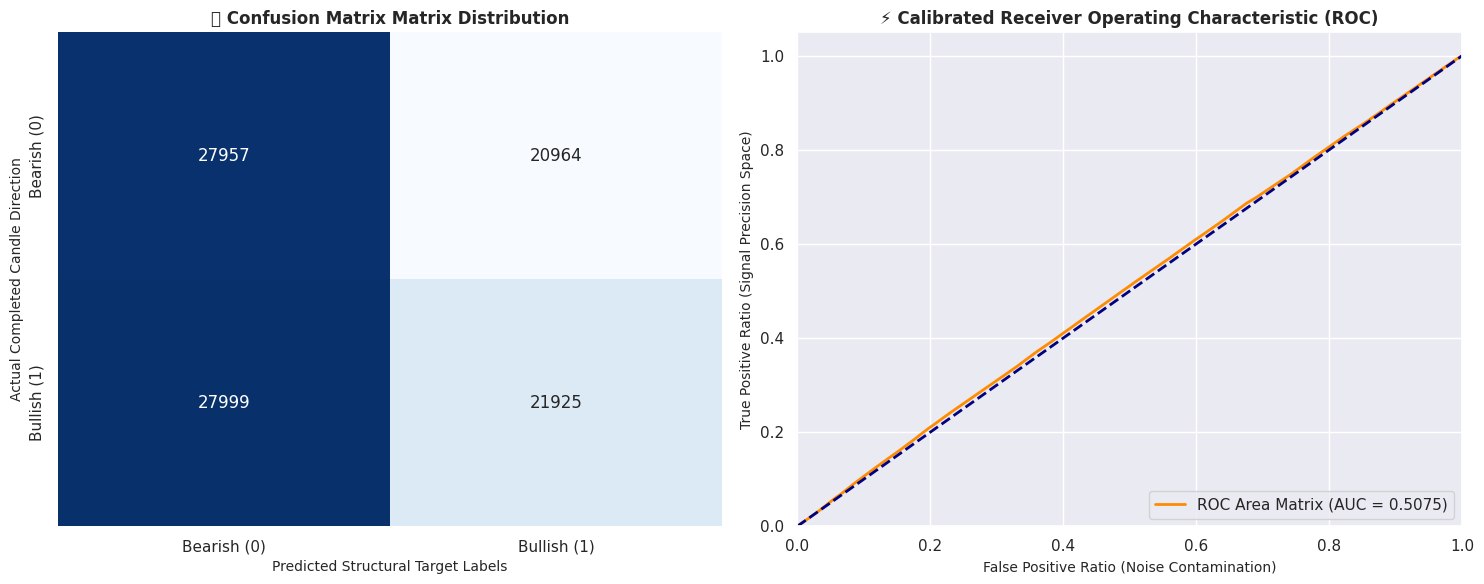

✅ Visualization pipeline fully plotted. Structural review completed.


In [20]:
# ==============================================================================
# 🥇 PHASE 13: PRODUCTION METRICS VISUALIZATION DASHBOARD
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

print("==========================================================")
print("📊 PHASE 13: GENERATING PERFORMANCE EVALUATION GRAPHS")
print("==========================================================")

# Set plotting style parameters for clean interface appearance
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ------------------------------------------------------------------------------
# GRAPH 1: Confusion Matrix Heatmap (Real Distributions vs Predictions)
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_test, test_calibrated_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Bearish (0)', 'Bullish (1)'],
            yticklabels=['Bearish (0)', 'Bullish (1)'])
axes[0].set_title('🥇 Confusion Matrix Matrix Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Structural Target Labels', fontsize=10)
axes[0].set_ylabel('Actual Completed Candle Direction', fontsize=10)

# ------------------------------------------------------------------------------
# GRAPH 2: Receiver Operating Characteristic (ROC) Curve Profile
# ------------------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, test_calibrated_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Area Matrix (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('⚡ Calibrated Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Ratio (Noise Contamination)', fontsize=10)
axes[1].set_ylabel('True Positive Ratio (Signal Precision Space)', fontsize=10)
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

print("==========================================================")
print("✅ Visualization pipeline fully plotted. Structural review completed.")
print("==========================================================")

In [ ]:
# import os
# import zipfile
# from google.colab import files

# print("==========================================================")
# print("⚡ FAST-ZIP ARCHIVE ENGINE (FILTERING SYSTEM FILES)")
# print("==========================================================")

# # 1. Zip file ka naam
# zip_filename = "trading_project_fast_backup_update.zip"

# # 2. Sirf in files/folders ko pack karna hai
# target_files = [f for f in os.listdir() if f.endswith('.pkl') or f.endswith('.csv') or f.endswith('.html')]
# target_folders = ['src'] # Agar aapka src folder hai

# with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#     # Files add karein
#     for file in target_files:
#         if os.path.isfile(file):
#             zipf.write(file)
#             print(f"✓ Added File: {file}")

#     # src folder add karein (agar exists)
#     for folder in target_folders:
#         if os.path.exists(folder):
#             for root, dirs, files_in_dir in os.walk(folder):
#                 for file in files_in_dir:
#                     file_path = os.path.join(root, file)
#                     zipf.write(file_path, os.path.relpath(file_path, os.path.join(folder, '..')))
#             print(f"✓ Added Folder: {folder}/")

# # 3. Direct download
# print("----------------------------------------------------------")
# print("🚀 Compression complete! Triggering download...")
# files.download(zip_filename)

In [ ]:
# gold_rr_lstm_nn.save('gold_multitask_lstm_best_model.keras')
# print("✓ Model successfully saved as 'gold_multitask_lstm_best_model.keras'")

# # 2. Save the validation data slice (for rolling predictions tomorrow)
# val_df_slice.to_csv('gold_validation_slice.csv', index=False)
# print("✓ Validation data slice successfully saved as 'gold_validation_slice.csv'")

In [ ]:
# from google.colab import files

# print("Downloading files to your local system... Please allow pop-ups if prompted.")

# # Download model
# files.download('gold_multitask_lstm_best_model.keras')

# # Download dataset slice
# files.download('gold_validation_slice.csv')